#**유통 판매량 예측 및 재고 최적화**
## **단계2 : 모델링을 위한 데이터 전처리**

# **0.미션**

* 단계1 상품별 데이터셋 만들기
    * 가설로 도출된 변수를 반영한 데이터셋을 상품별로 생성
* 단계2 기초 모델 생성
    * base line model : dense layer만 이용해서 기초 모델 생성
    * LSTM, CNN 알고리즘을 이용해서 기초 모델 생성

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|3|6|
|42|FM001|Agricultural products|Grocery|3|5|


# **1.환경설정**

* 세부 요구사항
    * 구글콜랩
        * 구글 드라이브 바로 밑에 project 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 라이브러리 로딩
        * 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### **(1) 경로 설정**

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = '/content/gdrive/Othercomputers/내 노트북/aivle6-practice/mini-project-6/'

### **(2) 라이브러리 설치 및 불러오기**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

from keras.models import Sequential
from keras.backend import clear_session
from keras.layers import Dense, LSTM, Conv1D, Flatten, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings("ignore")

In [4]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [5]:
# 예측 결과 시각화
def plot_model_result(y_train, y_val, pred) :

    y_train = pd.Series(y_train)
    y_val = pd.Series(y_val)
    y_val.index = range(len(y_train), len(y_train) + len(y_val))

    pred = pd.Series(pred.reshape(-1,), index = y_val.index)

    # 전체 시각화
    plt.figure(figsize = (20,12))
    plt.subplot(2,1,1)
    plt.plot(y_train, label = 'train')
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.subplot(2,1,2)
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.show()

### **(3) 데이터 불러오기**

In [6]:
oil_price = pd.read_csv(path + 'train/oil_price_train.csv')
orders = pd.read_csv(path + 'train/orders_train.csv')
sales = pd.read_csv(path + 'train/sales_train.csv')
products = pd.read_csv(path + 'train/products.csv')
stores = pd.read_csv(path + 'train/stores.csv')

sales['Date'] = pd.to_datetime(sales['Date'] )
oil_price['Date'] = pd.to_datetime(oil_price['Date'] )
orders['Date'] = pd.to_datetime(orders['Date'] )

# **2.데이터셋 구성하기**

* 세부 요구사항
    * 상품코드 별로 각각 데이터셋을 구성해야 합니다.
    * 도출된 변수들을 포함하는 데이터셋을 구성합니다.


In [7]:
# 유가정보
oil_price.head()

,Date,WTI_Price
0,2014-01-01,NaN
1,2014-01-02,95.14
2,2014-01-03,93.66
3,2014-01-06,93.12
4,2014-01-07,93.31


In [8]:
# 44매장 고객 방문수 df : orders_44
orders_44 = orders.loc[orders['Store_ID'] == 44]
orders_44

,Date,Store_ID,CustomerCount
39,2014-01-02,44,4422
86,2014-01-03,44,4167
133,2014-01-04,44,5341
180,2014-01-05,44,5123
227,2014-01-06,44,3917
...,...,...,...
57336,2017-02-24,44,4549
57389,2017-02-25,44,4619
57442,2017-02-26,44,3877
57495,2017-02-27,44,3961


In [9]:
# 44매장의 42제품 판매량 df : sales_44_42
sales_44_42 = sales.loc[(sales['Store_ID']==44) & (sales['Product_ID']==42)]
sales_44_42

,Date,Store_ID,Qty,Product_ID
658,2014-01-01,44,51.0,42
1469,2014-01-02,44,76.0,42
2280,2014-01-03,44,74.0,42
3091,2014-01-04,44,78.0,42
3902,2014-01-05,44,88.0,42
...,...,...,...,...
930878,2017-02-24,44,91.0,42
931689,2017-02-25,44,105.0,42
932500,2017-02-26,44,108.0,42
933311,2017-02-27,44,78.0,42


In [10]:
# 42 제품 정보
products.loc[products['Product_ID']==42]

,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price
15,42,FM001,Agricultural products,Grocery,2,5


In [11]:
# 44 지점 정보
stores.loc[stores['Store_ID']==44]

,Store_ID,City,State,Store_Type
43,44,Saint Paul,\tMinnesota,1


In [12]:
# 44지점과 같은 지점의 정
stores.loc[stores['State']=='\tMinnesota']

,Store_ID,City,State,Store_Type
0,1,Saint Paul,\tMinnesota,4
1,2,Saint Paul,\tMinnesota,4
2,3,Saint Paul,\tMinnesota,4
3,4,Saint Paul,\tMinnesota,4
5,6,Saint Paul,\tMinnesota,4
6,7,Saint Paul,\tMinnesota,4
7,8,Saint Paul,\tMinnesota,4
8,9,Saint Paul,\tMinnesota,2
9,10,Saint Paul,\tMinnesota,3
10,11,Minneapolis,\tMinnesota,2


In [13]:
# 44지점의 42제품과 동일 카테고리 제품 판매량 : sales_44
sales_44 = sales.loc[(sales['Store_ID']==44) & (sales['Product_ID'].isin([10,24,32,42]))]
sales_44

,Date,Store_ID,Qty,Product_ID
649,2014-01-01,44,0.000,10
656,2014-01-01,44,0.000,24
658,2014-01-01,44,51.000,42
660,2014-01-01,44,0.000,32
1460,2014-01-02,44,780.000,10
...,...,...,...,...
933313,2017-02-27,44,119.734,32
934113,2017-02-28,44,974.000,10
934120,2017-02-28,44,1057.687,24
934122,2017-02-28,44,87.000,42


In [14]:
# 판매량 스케일링
scaler = MinMaxScaler()
sales_scaled_values = scaler.fit_transform(sales_44[['Qty']])
sales_44['Qty_s'] = sales_scaled_values
sales_44

,Date,Store_ID,Qty,Product_ID,Qty_s
649,2014-01-01,44,0.000,10,0.000000
656,2014-01-01,44,0.000,24,0.000000
658,2014-01-01,44,51.000,42,0.024356
660,2014-01-01,44,0.000,32,0.000000
1460,2014-01-02,44,780.000,10,0.372499
...,...,...,...,...,...
933313,2017-02-27,44,119.734,32,0.057180
934113,2017-02-28,44,974.000,10,0.465146
934120,2017-02-28,44,1057.687,24,0.505112
934122,2017-02-28,44,87.000,42,0.041548


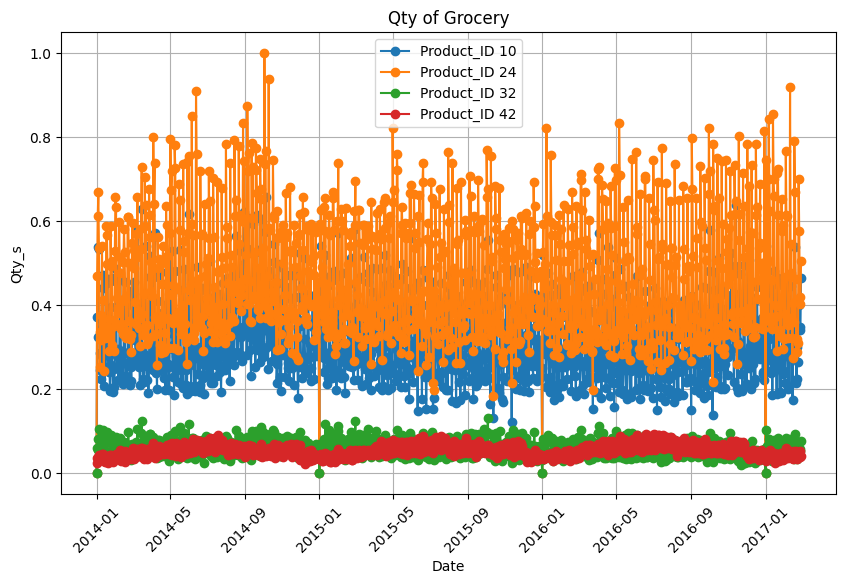

In [15]:
plt.figure(figsize=(10, 6))
for pid in [10,24,32,42]:
    subset = sales_44[sales_44['Product_ID'] == pid]
    plt.plot(subset['Date'], subset['Qty_s'], marker='o', label=f'Product_ID {pid}')

plt.title('Qty of Grocery')
plt.xlabel('Date')
plt.ylabel('Qty_s')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [16]:

# 분기 정보를 새로운 열로 추가
sales_44['Quarter'] = sales_44['Date'].dt.to_period('Q')

# 분기별, 상품별 판매량을 집계
quarterly_sales = sales_44.groupby(['Quarter', 'Product_ID'])['Qty'].sum().reset_index()

# 결과 확인
quarterly_sales

,Quarter,Product_ID,Qty
0,2014Q1,10,59424.000000
1,2014Q1,24,83342.419470
2,2014Q1,32,11561.511458
3,2014Q1,42,7665.000000
4,2014Q2,10,59663.000000
5,2014Q2,24,90435.519330
6,2014Q2,32,11673.211198
7,2014Q2,42,11089.000000
8,2014Q3,10,68305.000000
9,2014Q3,24,97677.725340


In [17]:
# 분기를 float64로 변환하는 함수
def period_to_float(period):
    year = period.year
    quarter = period.quarter
    return year + (quarter - 1) / 4.0

# 분기 데이터 변환
quarterly_sales['Quarter'] = quarterly_sales['Quarter'].apply(period_to_float)

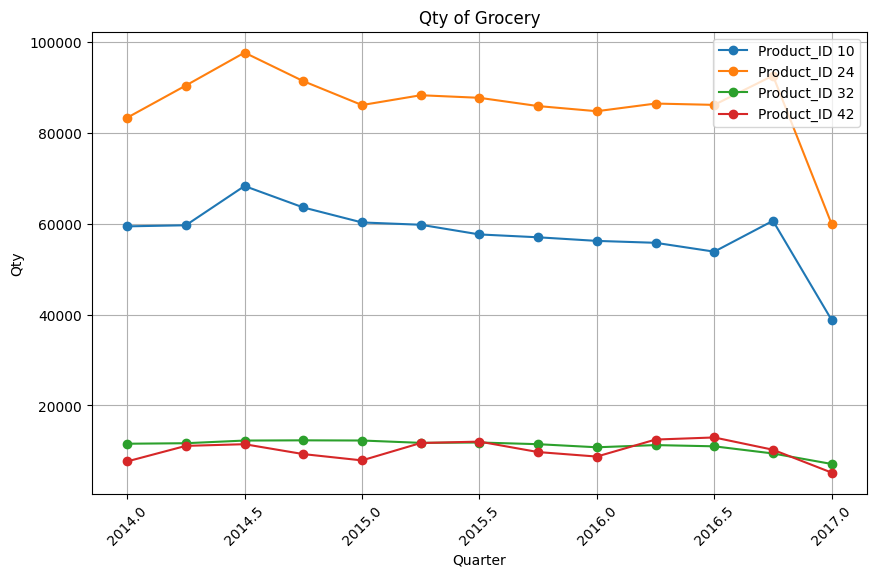

In [18]:
plt.figure(figsize=(10, 6))
for pid in [10,24,32,42]:
    subset = quarterly_sales[quarterly_sales['Product_ID'] == pid]
    plt.plot(subset['Quarter'], subset['Qty'], marker='o', label=f'Product_ID {pid}')

plt.title('Qty of Grocery')
plt.xlabel('Quarter')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [19]:
#농산물 데이터 전처리2
df_hk = pd.merge(sales, stores, how = 'inner', on = 'Store_ID')
df_hk = pd.merge(df_hk, products, how = 'inner', on = 'Product_ID')
df_hk = pd.merge(df_hk, oil_price, how = 'left', on = 'Date')
df_hk = pd.merge(df_hk, orders, how = 'inner', on = ['Date', 'Store_ID'])
df_hk.head()

,Date,Store_ID,Qty,Product_ID,City,State,Store_Type,Product_Code,SubCategory,Category,LeadTime,Price,WTI_Price,CustomerCount
0,2014-01-01,25,1415.000,3,Olympia,Washington,4,DB001,Beverage,Drink,2,8,NaN,840
1,2014-01-01,25,186.452,5,Olympia,Washington,4,FB001,BAKERY,Food,2,6,NaN,840
2,2014-01-01,25,232.000,7,Olympia,Washington,4,HC001,Cleaning,Household Goods,2,15,NaN,840
3,2014-01-01,25,358.000,8,Olympia,Washington,4,FM001,Yogurt,Food,2,4,NaN,840
4,2014-01-01,25,64.000,10,Olympia,Washington,4,GE001,EGGS,Grocery,2,5,NaN,840


In [20]:
df_hk = df_hk.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
df_hk.isna().sum()

,0
Date,0
Store_ID,0
Qty,0
Product_ID,0
City,0
State,0
Store_Type,0
Product_Code,0
SubCategory,0
Category,0


In [21]:
df_hk = df_hk[df_hk['Date'].dt.year != 2017]
df_hk.tail()

,Date,Store_ID,Qty,Product_ID,City,State,Store_Type,Product_Code,SubCategory,Category,LeadTime,Price,WTI_Price,CustomerCount
818328,2016-12-31,54,277.000000,38,LA,\tCalifornia,3,DA001,Wine,Drink,2,12,53.065373,1647
818329,2016-12-31,54,61.119003,24,LA,\tCalifornia,3,GM001,Meats,Grocery,3,17,53.064509,1647
818330,2016-12-31,54,10.000000,27,LA,\tCalifornia,3,HH001,Home Appliances,Household Goods,2,150,53.063644,1647
818331,2016-12-31,54,52.000000,29,LA,\tCalifornia,3,FP001,Prepared,Food,2,18,53.062780,1647
818332,2016-12-31,54,2.000000,32,LA,\tCalifornia,3,GS001,Seafood,Grocery,3,34,53.061915,1647


## **(1) 상품 : 3 - Beverage**

In [22]:
#음료수 데이터 전처리
# 대상 매장 결합 후 결측치 선형보간
id=44
order_44=orders.loc[orders['Store_ID'] == id]
drink=products.loc[products['SubCategory'] == 'Beverage']
sales_44=sales.loc[(sales['Store_ID'] == id)&(sales['Product_ID'] == 3)]
sales_44.head(20)
t1=pd.merge(order_44,sales_44,how='inner')
t2=pd.merge(t1,order_44,how='inner')
total=pd.merge(t2,oil_price,how='outer')
total.drop(columns=['Store_ID','Product_ID'],inplace=True)
total['day']=total['Date'].dt.weekday
total['month']=total['Date'].dt.month
#total['oil_range']=pd.cut(total['WTI_Price'],bins=[0,30,40,50,60,70,80,90,100,110],labels=['0~30','31~40','41~50','51~60','61~70','71~80','81~90','91~100','101~110'])
#total['oil_range'] = total['oil_range'].fillna(method='bfill')
total['WTI_Price'] = total['WTI_Price'].interpolate(method='linear')
total['CustomerCount']=total['CustomerCount'].interpolate(method='linear')
total['Qty']=total['Qty'].interpolate(method='linear')
total['season']=total['month'].map({1:4,2:4,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:4,12:4})

#total.drop(index=[total['Qty'].argmax(),total['Qty'].argmax() - 1], axis=0, inplace=True)

#total.replace({'day':{0:'mon',1:'tue',2:'wen',3:'thu',4:'fri',5:'sat',6:'sun'}},inplace=True)

total.drop(columns=['Date'],inplace=True)
total['2d_later']=total['Qty'].shift(-2)
total.dropna(inplace=True)
total=pd.get_dummies(data=total,columns=['day','season'],drop_first=True)
total.head()


total.head(20)

,CustomerCount,Qty,WTI_Price,month,2d_later,day_1,day_2,day_3,day_4,day_5,day_6,season_2,season_3,season_4
1,4422.0,9853.0,95.140000,1,15153.0,False,False,True,False,False,False,False,False,True
2,4167.0,8647.0,93.660000,1,15606.0,False,False,False,True,False,False,False,False,True
3,5341.0,15153.0,93.480000,1,7900.0,False,False,False,False,True,False,False,False,True
4,5123.0,15606.0,93.300000,1,7188.0,False,False,False,False,False,True,False,False,True
5,3917.0,7900.0,93.120000,1,8800.0,False,False,False,False,False,False,False,False,True
6,3663.0,7188.0,93.310000,1,6606.0,True,False,False,False,False,False,False,False,True
7,4254.0,8800.0,91.900000,1,7051.0,False,True,False,False,False,False,False,False,True
8,3723.0,6606.0,91.360000,1,12599.0,False,False,True,False,False,False,False,False,True
9,4010.0,7051.0,92.390000,1,13383.0,False,False,False,True,False,False,False,False,True
10,5053.0,12599.0,92.076667,1,7086.0,False,False,False,False,True,False,False,False,True


In [23]:
order_44 = orders.loc[orders['Store_ID'] == 44]
sales_44 = sales.loc[(sales['Store_ID'] == 44)]

t1 = pd.merge(order_44, sales_44, how='inner')
t2 = pd.merge(t1, products, on='Product_ID', how='outer')
t2.drop(columns=['Store_ID', 'CustomerCount', 'Product_ID', 'Product_Code', 'Category', 'LeadTime', 'Price'], inplace=True)
t2

# 'SubCategory' 값을 컬럼으로 변환하여 'Qty'를 해당하는 값으로 채웁니다.
df_pivoted = t2.pivot_table(index='Date', columns='SubCategory', values='Qty', aggfunc='sum')
df_pivoted

SubCategory,Agricultural products,BAKERY,Beverage,Cleaning,EGGS,Frozen,Gardening Tools,Home Appliances,Kitchen,Meats,Milk,Prepared,Seafood,Wine,Yogurt
Date,,,,,,,,,,,,,,,
2014-01-02,76.0,1302.470,9853.0,3181.0,780.0,600.931,11.0,41.0,79.0,981.64400,9647.0,654.149,124.9780,289.0,2991.0
2014-01-03,74.0,1243.054,8647.0,3036.0,677.0,621.938,7.0,40.0,129.0,1278.90810,8879.0,514.697,115.0889,333.0,2694.0
2014-01-04,78.0,1882.780,15153.0,4466.0,1126.0,883.348,18.0,90.0,115.0,1398.66600,14188.0,749.997,171.1640,531.0,4355.0
2014-01-05,88.0,2029.317,15606.0,4582.0,1118.0,854.104,10.0,96.0,103.0,1119.53500,14490.0,842.430,217.2520,0.0,4228.0
2014-01-06,65.0,992.359,7900.0,2536.0,596.0,429.764,10.0,33.0,85.0,526.12897,7614.0,494.158,97.2330,183.0,2323.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-24,91.0,1743.020,10208.0,2259.0,715.0,467.000,19.0,32.0,212.0,1466.85600,10630.0,447.948,153.4990,481.0,2530.0
2017-02-25,105.0,2006.152,12361.0,2839.0,839.0,542.060,49.0,54.0,261.0,1208.54100,12978.0,526.739,115.1100,712.0,3341.0
2017-02-26,108.0,1699.694,10108.0,3032.0,711.0,405.000,66.0,34.0,193.0,878.53400,10899.0,469.051,108.9200,351.0,2777.0


In [24]:
correlation_matrix = df_pivoted.corr()
beverage_corr = correlation_matrix['Beverage']
beverage_corr.sort_values(ascending=False)

,Beverage
SubCategory,
Beverage,1.000000
BAKERY,0.809183
Home Appliances,0.804877
Yogurt,0.789685
Milk,0.760803
Cleaning,0.714474
EGGS,0.670100
Prepared,0.645309
Seafood,0.472226


In [25]:
oil_price_test = pd.read_csv(path + 'test/oil_price_test.csv')
orders_test = pd.read_csv(path + 'test/orders_test.csv')
sales_test = pd.read_csv(path + 'test/sales_test.csv')
products_test = pd.read_csv(path + 'test/products.csv')
stores_test = pd.read_csv(path + 'test/stores.csv')

sales_test['Date'] = pd.to_datetime(sales_test['Date'] )
oil_price_test['Date'] = pd.to_datetime(oil_price_test['Date'] )
orders_test['Date'] = pd.to_datetime(orders_test['Date'] )

In [26]:
orders_test

,Date,Store_ID,CustomerCount
0,2017-03-01,1,1873
1,2017-03-01,2,1853
2,2017-03-01,3,3130
3,2017-03-01,4,1424
4,2017-03-01,5,1418
...,...,...,...
1638,2017-03-31,49,3525
1639,2017-03-31,50,2521
1640,2017-03-31,51,1794
1641,2017-03-31,53,1131


In [27]:
order_test_44 = orders_test.loc[orders_test['Store_ID'] == 44]
sales_test_44 = sales_test.loc[(sales_test['Store_ID'] == 44)]

t1 = pd.merge(order_test_44, sales_test_44, how='inner')
t2 = pd.merge(t1, products_test, on='Product_ID', how='outer')
t2.drop(columns=['Store_ID', 'CustomerCount', 'Product_ID', 'Product_Code', 'Category', 'LeadTime', 'Price'], inplace=True)
t2

# 'SubCategory' 값을 컬럼으로 변환하여 'Qty'를 해당하는 값으로 채웁니다.
df_pivoted_test = t2.pivot_table(index='Date', columns='SubCategory', values='Qty', aggfunc='sum')

In [28]:
correlation_matrix = df_pivoted_test.corr()
beverage_corr = correlation_matrix['Beverage']
beverage_corr.sort_values(ascending=False)

,Beverage
SubCategory,
Beverage,1.000000
Yogurt,0.985427
BAKERY,0.977657
Milk,0.957632
Cleaning,0.926800
EGGS,0.902319
Prepared,0.888340
Frozen,0.848024
Home Appliances,0.846640


In [29]:
id=44

order_44 = orders.loc[orders['Store_ID'] == id]

drink = products.loc[products['SubCategory'] == 'Beverage']

sales_44 = sales.loc[(sales['Store_ID'] == id) & (sales['Product_ID'] == 3)]

t1 = pd.merge(order_44, sales_44, how='inner')
t2 = pd.merge(t1, order_44, how='inner')
df_bev_oil = pd.merge(t2, oil_price, how='outer')

df_bev_oil.drop(columns=['Store_ID', 'Product_ID'], inplace=True)
df_bev_oil['day'] = df_bev_oil['Date'].dt.weekday
df_bev_oil['month']=df_bev_oil['Date'].dt.month
df_bev_oil['oil_range']=pd.cut(df_bev_oil['WTI_Price'],bins=[0,30,40,50,60,70,80,90,100,110],labels=['0~30','31~40','41~50','51~60','61~70','71~80','81~90','91~100','101~110'])
df_bev_oil['oil_range'] = df_bev_oil['oil_range'].fillna(method='bfill')
df_bev_oil['WTI_Price'] = df_bev_oil['WTI_Price'].interpolate(method='linear')
df_bev_oil['CustomerCount']=df_bev_oil['CustomerCount'].interpolate(method='linear')
df_bev_oil['Qty']=df_bev_oil['Qty'].interpolate(method='linear')

df_bev_oil['y'] = df_bev_oil['Qty'].shift(-2)
df_bev_oil = df_bev_oil[1:-2]

dumm_cols = ['oil_range']
df_bev_oil = pd.get_dummies(data=df_bev_oil, columns=dumm_cols)

df_bev = pd.merge(df_bev_oil, df_pivoted[['BAKERY', 'Home Appliances', 'Yogurt']], on='Date')

df_bev

,Date,CustomerCount,Qty,WTI_Price,day,month,y,oil_range_0~30,oil_range_31~40,oil_range_41~50,oil_range_51~60,oil_range_61~70,oil_range_71~80,oil_range_81~90,oil_range_91~100,oil_range_101~110,BAKERY,Home Appliances,Yogurt
0,2014-01-02,4422.0,9853.0,95.140000,3,1,15153.0,False,False,False,False,False,False,False,True,False,1302.470,41.0,2991.0
1,2014-01-03,4167.0,8647.0,93.660000,4,1,15606.0,False,False,False,False,False,False,False,True,False,1243.054,40.0,2694.0
2,2014-01-04,5341.0,15153.0,93.480000,5,1,7900.0,False,False,False,False,False,False,False,True,False,1882.780,90.0,4355.0
3,2014-01-05,5123.0,15606.0,93.300000,6,1,7188.0,False,False,False,False,False,False,False,True,False,2029.317,96.0,4228.0
4,2014-01-06,3917.0,7900.0,93.120000,0,1,8800.0,False,False,False,False,False,False,False,True,False,992.359,33.0,2323.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,2017-02-22,3834.0,7856.0,53.610000,2,2,10208.0,False,False,False,True,False,False,False,False,False,1389.665,30.0,2206.0
1140,2017-02-23,3955.0,8018.0,54.480000,3,2,12361.0,False,False,False,True,False,False,False,False,False,1400.192,25.0,2099.0
1141,2017-02-24,4549.0,10208.0,53.990000,4,2,10108.0,False,False,False,True,False,False,False,False,False,1743.020,32.0,2530.0
1142,2017-02-25,4619.0,12361.0,54.006667,5,2,10006.0,False,False,False,True,False,False,False,False,False,2006.152,54.0,3341.0


In [30]:
id_test = 44

order_44_test = orders_test.loc[orders_test['Store_ID'] == id_test]

drink_test = products_test.loc[products_test['SubCategory'] == 'Beverage']

sales_44_test = sales_test.loc[(sales_test['Store_ID'] == id_test) & (sales_test['Product_ID'] == 3)]

t1_test = pd.merge(order_44_test, sales_44_test, how='inner')
t2_test = pd.merge(t1_test, order_44_test, how='inner')
df_bev_oil_test = pd.merge(t2_test, oil_price_test, how='outer')

df_bev_oil_test.drop(columns=['Store_ID', 'Product_ID'], inplace=True)
df_bev_oil_test['day'] = df_bev_oil_test['Date'].dt.weekday
df_bev_oil_test['month'] = df_bev_oil_test['Date'].dt.month
df_bev_oil_test['oil_range'] = pd.cut(df_bev_oil_test['WTI_Price'], bins=[0, 30, 40, 50, 60, 70, 80, 90, 100, 110],
                                      labels=['0~30', '31~40', '41~50', '51~60', '61~70', '71~80', '81~90', '91~100', '101~110'])

df_bev_oil_test['oil_range'] = df_bev_oil_test['oil_range'].fillna(method='bfill')
df_bev_oil_test['WTI_Price'] = df_bev_oil_test['WTI_Price'].interpolate(method='linear')
df_bev_oil_test['CustomerCount'] = df_bev_oil_test['CustomerCount'].interpolate(method='linear')
df_bev_oil_test['Qty'] = df_bev_oil_test['Qty'].interpolate(method='linear')

df_bev_oil_test['y'] = df_bev_oil_test['Qty'].shift(-2)
df_bev_oil_test = df_bev_oil_test[1:-2]

dumm_cols_test = ['oil_range']
df_bev_oil_test = pd.get_dummies(data=df_bev_oil_test, columns=dumm_cols_test)

df_bev_test = pd.merge(df_bev_oil_test, df_pivoted_test[['BAKERY', 'Home Appliances', 'Yogurt']], on='Date')

df_bev_test

,Date,CustomerCount,Qty,WTI_Price,day,month,y,oil_range_0~30,oil_range_31~40,oil_range_41~50,oil_range_51~60,oil_range_61~70,oil_range_71~80,oil_range_81~90,oil_range_91~100,oil_range_101~110,BAKERY,Home Appliances,Yogurt
0,2017-03-02,3882,8918.0,52.630000,3,3,16991.0,False,False,False,True,False,False,False,False,False,1407.037,51.0,2234.0
1,2017-03-03,4483,10257.0,53.330000,4,3,18304.0,False,False,False,True,False,False,False,False,False,1710.550,29.0,2888.0
2,2017-03-04,5382,16991.0,53.283333,5,3,8413.0,False,False,False,True,False,False,False,False,False,2430.925,53.0,4317.0
3,2017-03-05,5423,18304.0,53.236667,6,3,8360.0,False,False,False,True,False,False,False,False,False,2742.407,74.0,4579.0
4,2017-03-06,3882,8413.0,53.190000,0,3,8632.0,False,False,False,True,False,False,False,False,False,1400.493,28.0,2333.0
5,2017-03-07,3828,8360.0,52.680000,1,3,8816.0,False,False,False,True,False,False,False,False,False,1230.641,27.0,2275.0
6,2017-03-08,4111,8632.0,49.830000,2,3,10087.0,False,False,True,False,False,False,False,False,False,1364.681,29.0,2372.0
7,2017-03-09,3560,8816.0,48.750000,3,3,15131.0,False,False,True,False,False,False,False,False,False,1366.626,19.0,2210.0
8,2017-03-10,4183,10087.0,48.050000,4,3,18556.0,False,False,True,False,False,False,False,False,False,1580.520,29.0,2651.0
9,2017-03-11,5080,15131.0,48.016667,5,3,8803.0,False,False,True,False,False,False,False,False,False,2377.645,53.0,3985.0


## **(2) 상품 : 12 - Milk**

In [31]:
def make_dataset(Product_ID):

    # 판매 데이터에서 상품 ID에 맞는 데이터만 필터링
    product_sales = sales[sales['Product_ID'] == Product_ID].copy()

    # 44번 매장 데이터만 필터링
    product_sales = product_sales[product_sales['Store_ID'] == 44]

    # 주문 데이터와 병합하여 고객 방문 수를 추가
    product_sales = product_sales.merge(
        orders[['Date', 'Store_ID', 'CustomerCount']],
        on=['Date', 'Store_ID'],
        how='left'
    )

    # 유가 데이터의 결측치를 선형 보간
    oil_price['WTI_Price'] = oil_price['WTI_Price'].interpolate(method='linear')

    # 유가 7일 이동 평균 계산
    oil_price['WTI_Price'] = oil_price['WTI_Price'].rolling(window=7, min_periods=1).mean()

    # 유가 데이터와 병합
    product_sales = product_sales.merge(oil_price[['Date', 'WTI_Price']], on='Date', how='left')

    # 결측치 채우기
    product_sales['WTI_Price'].fillna(method='ffill', inplace=True)

    product_sales['Year'] = product_sales['Date'].dt.year
    product_sales['Month'] = product_sales['Date'].dt.month
    product_sales['Day'] = product_sales['Date'].dt.day
    product_sales['Weekday'] = product_sales['Date'].dt.weekday
    product_sales['Is_Weekend'] = product_sales['Weekday'].apply(lambda x: 1 if x >= 5 else 0)

    # 전날 판매량 추가
    product_sales['Prev_Qty'] = product_sales['Qty'].shift(1)
    product_sales['Prev_Qty'].fillna(0, inplace=True)

    # 주간 판매량 합산 계산
    product_sales['Date'] = pd.to_datetime(product_sales['Date'])
    product_sales['Week'] = product_sales['Date'].dt.isocalendar().week
    weekly_sales = product_sales.groupby(['Store_ID', 'Product_ID', 'Year', 'Week'])['Qty'].sum().reset_index()
    product_sales = product_sales.merge(weekly_sales, on=['Store_ID', 'Product_ID', 'Year', 'Week'], suffixes=('', '_Weekly'))

    # 타겟 변수 설정 (2일 후 판매량)
    product_sales['Target_Qty'] = product_sales['Qty'].shift(-2)
    product_sales = product_sales.drop(index=0)
    product_sales = product_sales.dropna()

    # 지정된 컬럼 삭제
    product_sales = product_sales.drop(columns=['Store_ID', 'Product_ID', 'Day', 'Week', 'Year'])

    return product_sales


In [32]:
data_12 = make_dataset(12)
data_12

,Date,Qty,CustomerCount,WTI_Price,Month,Weekday,Is_Weekend,Prev_Qty,Qty_Weekly,Target_Qty
1,2014-01-02,9647.0,4422.0,95.140000,1,3,0,0.0,72915.0,14188.0
2,2014-01-03,8879.0,4167.0,94.400000,1,4,0,9647.0,72915.0,14490.0
3,2014-01-04,14188.0,5341.0,94.400000,1,5,1,8879.0,72915.0,7614.0
4,2014-01-05,14490.0,5123.0,94.400000,1,6,1,14188.0,72915.0,7124.0
5,2014-01-06,7614.0,3917.0,93.973333,1,0,0,14490.0,59904.0,8683.0
...,...,...,...,...,...,...,...,...,...,...
1145,2017-02-22,8931.0,3834.0,53.497857,2,2,0,7374.0,66701.0,10630.0
1146,2017-02-23,8643.0,3955.0,53.679286,2,3,0,8931.0,66701.0,12978.0
1147,2017-02-24,10630.0,4549.0,53.805000,2,4,0,8643.0,66701.0,10899.0
1148,2017-02-25,12978.0,4619.0,53.805000,2,5,1,10630.0,66701.0,10618.0


In [33]:
# 결측치 확인
data_12.isna().sum()

,0
Date,0
Qty,0
CustomerCount,0
WTI_Price,0
Month,0
Weekday,0
Is_Weekend,0
Prev_Qty,0
Qty_Weekly,0
Target_Qty,0


## **(3) 상품 : 42 - Agricultural products**

In [34]:
orders_44['CustomerCount']

,CustomerCount
39,4422
86,4167
133,5341
180,5123
227,3917
...,...
57336,4549
57389,4619
57442,3877
57495,3961


In [35]:
df = pd.merge(sales_44_42,orders_44[['Date','CustomerCount']],on='Date')
df

,Date,Store_ID,Qty,Product_ID,CustomerCount
0,2014-01-02,44,76.0,42,4422
1,2014-01-03,44,74.0,42,4167
2,2014-01-04,44,78.0,42,5341
3,2014-01-05,44,88.0,42,5123
4,2014-01-06,44,65.0,42,3917
...,...,...,...,...,...
1141,2017-02-24,44,91.0,42,4549
1142,2017-02-25,44,105.0,42,4619
1143,2017-02-26,44,108.0,42,3877
1144,2017-02-27,44,78.0,42,3961


In [36]:
df.isnull().sum()

,0
Date,0
Store_ID,0
Qty,0
Product_ID,0
CustomerCount,0


In [37]:
df = df[['Date','Qty','CustomerCount']]
df

,Date,Qty,CustomerCount
0,2014-01-02,76.0,4422
1,2014-01-03,74.0,4167
2,2014-01-04,78.0,5341
3,2014-01-05,88.0,5123
4,2014-01-06,65.0,3917
...,...,...,...
1141,2017-02-24,91.0,4549
1142,2017-02-25,105.0,4619
1143,2017-02-26,108.0,3877
1144,2017-02-27,78.0,3961


In [38]:
# 일주일전 판매량 붙이기
df['7days_before_Qty'] = df['Qty'].shift(7)
df

,Date,Qty,CustomerCount,7days_before_Qty
0,2014-01-02,76.0,4422,NaN
1,2014-01-03,74.0,4167,NaN
2,2014-01-04,78.0,5341,NaN
3,2014-01-05,88.0,5123,NaN
4,2014-01-06,65.0,3917,NaN
...,...,...,...,...
1141,2017-02-24,91.0,4549,109.0
1142,2017-02-25,105.0,4619,93.0
1143,2017-02-26,108.0,3877,109.0
1144,2017-02-27,78.0,3961,76.0


In [39]:
# target 붙이기
df['2days_later_Qty'] = df['Qty'].shift(-2)
df

,Date,Qty,CustomerCount,7days_before_Qty,2days_later_Qty
0,2014-01-02,76.0,4422,NaN,78.0
1,2014-01-03,74.0,4167,NaN,88.0
2,2014-01-04,78.0,5341,NaN,65.0
3,2014-01-05,88.0,5123,NaN,78.0
4,2014-01-06,65.0,3917,NaN,73.0
...,...,...,...,...,...
1141,2017-02-24,91.0,4549,109.0,108.0
1142,2017-02-25,105.0,4619,93.0,78.0
1143,2017-02-26,108.0,3877,109.0,87.0
1144,2017-02-27,78.0,3961,76.0,NaN


In [40]:
# 결측치 처리
df['7days_before_Qty'].fillna(df['7days_before_Qty'].mean(), inplace=True)
df

,Date,Qty,CustomerCount,7days_before_Qty,2days_later_Qty
0,2014-01-02,76.0,4422,113.317823,78.0
1,2014-01-03,74.0,4167,113.317823,88.0
2,2014-01-04,78.0,5341,113.317823,65.0
3,2014-01-05,88.0,5123,113.317823,78.0
4,2014-01-06,65.0,3917,113.317823,73.0
...,...,...,...,...,...
1141,2017-02-24,91.0,4549,109.000000,108.0
1142,2017-02-25,105.0,4619,93.000000,78.0
1143,2017-02-26,108.0,3877,109.000000,87.0
1144,2017-02-27,78.0,3961,76.000000,NaN


In [41]:
#결측치 처리 : 2days_later_Qty
df['2days_later_Qty'].fillna(df['2days_later_Qty'].mean(), inplace=True)
df

,Date,Qty,CustomerCount,7days_before_Qty,2days_later_Qty
0,2014-01-02,76.0,4422,113.317823,78.00
1,2014-01-03,74.0,4167,113.317823,88.00
2,2014-01-04,78.0,5341,113.317823,65.00
3,2014-01-05,88.0,5123,113.317823,78.00
4,2014-01-06,65.0,3917,113.317823,73.00
...,...,...,...,...,...
1141,2017-02-24,91.0,4549,109.000000,108.00
1142,2017-02-25,105.0,4619,93.000000,78.00
1143,2017-02-26,108.0,3877,109.000000,87.00
1144,2017-02-27,78.0,3961,76.000000,113.25


In [42]:
#농산물 데이터 전처리2
category = df_hk.loc[(df_hk['Store_ID'] == 44) & (df_hk['Category'] == 'Grocery')]
category.head()
category['SubCategory'].unique()

array(['EGGS', 'Meats', 'Agricultural products', 'Seafood'], dtype=object)

In [43]:
meat = category.loc[category['SubCategory'] == 'Meats'][['Qty','Date']]
meat = meat.rename(columns={'Qty': 'meat_Qty'})
meat

,meat_Qty,Date
596,981.64400,2014-01-02
1302,1278.90810,2014-01-03
2008,1398.66600,2014-01-04
2714,1119.53500,2014-01-05
3420,526.12897,2014-01-06
...,...,...
815009,716.01800,2016-12-27
815805,973.26500,2016-12-28
816601,951.77400,2016-12-29
817397,1702.67200,2016-12-30


In [44]:
#육류 가격과 농산물이 연관성이 있다고 판단되어 해당 컬럼 추가
tdf = df_hk.loc[(df_hk['Store_ID'] == 44) & (df_hk['Product_ID']==42)]
tdf = pd.merge(tdf, meat, how = 'left', on = 'Date')

tdf.head()
tdf['WeekDay'] = tdf['Date'].dt.day_name()
tdf['Month'] =  tdf['Date'].dt.month
st_df = tdf.drop(['Store_ID','LeadTime','Store_Type','City', 'State','SubCategory','Product_Code','Category','Product_ID','Price'], axis=1)
st_df
st_df.head(10)

,Date,Qty,WTI_Price,CustomerCount,meat_Qty,WeekDay,Month
0,2014-01-02,76.0,95.140000,4422,981.64400,Thursday,1
1,2014-01-03,74.0,93.660000,4167,1278.90810,Friday,1
2,2014-01-04,78.0,93.436815,5341,1398.66600,Saturday,1
3,2014-01-05,88.0,93.167006,5123,1119.53500,Sunday,1
4,2014-01-06,65.0,93.120000,3917,526.12897,Monday,1
5,2014-01-07,78.0,93.310000,3663,700.50600,Tuesday,1
6,2014-01-08,73.0,91.900000,4254,789.43200,Wednesday,1
7,2014-01-09,78.0,91.360000,3723,663.80400,Thursday,1
8,2014-01-10,96.0,92.390000,4010,1133.06790,Friday,1
9,2014-01-11,67.0,92.001493,5053,741.45800,Saturday,1


# **3.Baseline Model**

* **세부 요구사항**
    * 데이터 준비
        * 스케일링
            * 교과서 적으로는 데이터 분할 이후 스케일링하는게 맞지만, 데이터 건수가 충분히 크다면, 스케일링을 먼저 하기도 합니다.
            * 여기서는 먼저 스케일링을 한 후 데이터 분할을 합니다.
        * 데이터 분할
            * 검증셋 구성 : 학습용 데이터에서 최근 60일을 검증셋으로 사용.

    * 모델링
        * Dense Layer 1개(output layer)만으로 모델을 생성합니다.
        * 모델의 검증 성능을 평가하고 기록합니다.
        * 평가 지표 : RMSE, MAE, MAPE, R2 Score


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1146 entries, 0 to 1145
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1146 non-null   datetime64[ns]
 1   Qty               1146 non-null   float64       
 2   CustomerCount     1146 non-null   int64         
 3   7days_before_Qty  1146 non-null   float64       
 4   2days_later_Qty   1146 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 44.9 KB


In [46]:
#스케일링
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
scaler = MinMaxScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

In [47]:
df

,Date,Qty,CustomerCount,7days_before_Qty,2days_later_Qty
0,2014-01-02,0.205298,0.326893,0.452436,0.218543
1,2014-01-03,0.192053,0.283296,0.452436,0.284768
2,2014-01-04,0.218543,0.484014,0.452436,0.132450
3,2014-01-05,0.284768,0.446743,0.452436,0.218543
4,2014-01-06,0.132450,0.240554,0.452436,0.185430
...,...,...,...,...,...
1141,2017-02-24,0.304636,0.348607,0.423841,0.417219
1142,2017-02-25,0.397351,0.360574,0.317881,0.218543
1143,2017-02-26,0.417219,0.233715,0.423841,0.278146
1144,2017-02-27,0.218543,0.248077,0.205298,0.451987


In [48]:
df.drop(columns='Date',inplace=True)
df

,Qty,CustomerCount,7days_before_Qty,2days_later_Qty
0,0.205298,0.326893,0.452436,0.218543
1,0.192053,0.283296,0.452436,0.284768
2,0.218543,0.484014,0.452436,0.132450
3,0.284768,0.446743,0.452436,0.218543
4,0.132450,0.240554,0.452436,0.185430
...,...,...,...,...
1141,0.304636,0.348607,0.423841,0.417219
1142,0.397351,0.360574,0.317881,0.218543
1143,0.417219,0.233715,0.423841,0.278146
1144,0.218543,0.248077,0.205298,0.451987


In [49]:
def preproc(data, y_scale = False) :
    target = 'target'
    x = data.drop(['Date', target], axis = 1)
    y = data.loc[:, target]

    # 가변수화
    x['WeekDay'] = pd.Categorical(x['WeekDay'], categories = ['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday' ])
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['WeekDay','Month'])

    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)

    # y scale
    if y_scale == True :
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else :
        y_min, y_max = np.nan, np.nan

    # 분할
    x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 60, shuffle = False)

    return x_train, x_val, y_train, y_val, scaler, y_min, y_max

## **(1) 상품 : 3 - Beverage**

### **1) 데이터 준비**

In [50]:
es=EarlyStopping(monitor='val_loss',patience=20,verbose=0,restore_best_weights=True)

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler


y = total['2d_later']
x = total.drop(columns=['2d_later'])


scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)  # x만 스케일링
y = scaler.fit_transform(y.values.reshape(-1, 1)) #y도 스케일링
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)


x_test, y_test = x_scaled[-60:], y[-60:]
x_train, y_train = x_scaled[:-60], y[:-60]


x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2)


print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)


x_train shape: (871, 13)
x_val shape: (218, 13)
x_test shape: (60, 13)


In [52]:
x = df_bev.drop(columns=['Date', 'y'])
y = df_bev['y']

In [53]:
scaler = MinMaxScaler()

x = scaler.fit_transform(x)

In [54]:
x_train = x[:-60]
x_val = x[-60:]
y_train = y[:-60]
y_val = y[-60:]

In [55]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1084, 17), (1084,), (60, 17), (60,))

In [56]:
x_test = df_bev_test.drop(columns=['Date', 'y'])
y_test = df_bev_test['y']

In [57]:
scaler = MinMaxScaler()

x_test = scaler.fit_transform(x_test)

In [58]:
x_test.shape

(28, 17)

### **2) 모델링**

In [59]:
model=Sequential()
model.add(Dense(1,input_dim=x_train.shape[1]))
model.add(Dense(8,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(8,activation='relu'))

model.add(Dense(1))

model.compile(loss='mse',optimizer='adam',metrics=['mse'])
model.summary()
hist=model.fit(x_train,y_train,epochs=100,batch_size=1,validation_data=(x_val,y_val),callbacks=[es]).history

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              18 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │              16 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,163 (86.57 KB)

 Trainable params: 22,163 (86.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 35109924.0000 - mse: 35109924.0000 - val_loss: 30278004.0000 - val_mse: 30278004.0000
Epoch 2/100
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 11660999.0000 - mse: 11660999.0000 - val_loss: 32017196.0000 - val_mse: 32017196.0000
Epoch 3/100
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 10949684.0000 - mse: 10949684.0000 - val_loss: 36060820.0000 - val_mse: 36060820.0000
Epoch 4/100
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 9277840.0000 - mse: 9277840.0000 - val_loss: 48964432.0000 - val_mse: 48964432.0000
Epoch 5/100
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 8928298.0000 - mse: 8928298.0000 - val_loss: 36922800.0000 - val_mse: 36922800.0000
Epoch 6/100
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8549260.0000 - mse: 8549260.0000 - val_loss: 42448848.0000 - val_mse: 42448848.0000
Epoch 7/100


KeyboardInterrupt: 

In [60]:
pred=model.predict(x_test)
pred=scaler.inverse_transform(pred)
y_test=scaler.inverse_transform(y_test)
pred=pd.DataFrame(pred)

dl_history_plot(hist)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step


ValueError: non-broadcastable output operand with shape (28,1) doesn't match the broadcast shape (28,17)

In [ ]:
#y_test,pred=y_test.reset_index(drop=True),pred.reset_index(drop=True)
plt.figure(figsize=(20,10))
plt.plot(y_test,label='y_test')
plt.plot(pred,label='pred')
plt.legend()
plt.show()

In [ ]:
model1 = Sequential([Input(shape=(x_train.shape[1],)),
                     Dense(1)])

model1.compile(optimizer=Adam(0.1), loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, restore_best_weights=True)

history = model1.fit(x_train, y_train, epochs=1000, validation_data=[x_val, y_val], callbacks=[es]).history

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 89923384.0000 - mae: 8749.8564 - val_loss: 142838576.0000 - val_mae: 11363.9512
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87715400.0000 - mae: 8670.4766 - val_loss: 142476608.0000 - val_mae: 11347.9561
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 86493944.0000 - mae: 8552.0420 - val_loss: 142114208.0000 - val_mae: 11331.9189
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87367888.0000 - mae: 8625.5254 - val_loss: 141752320.0000 - val_mae: 11315.8789
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 82132736.0000 - mae: 8389.3516 - val_loss: 141394640.0000 - val_mae: 11300.0029
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 85194560.0000 - mae: 8557.9170 - val_loss: 141033424.0000 - val_mae: 11283.9463
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 84295712.0000 - mae: 8454.7266 - val_loss: 140675280.0000 - val_mae: 11268.0020
Epoch 8/1000
34/34 

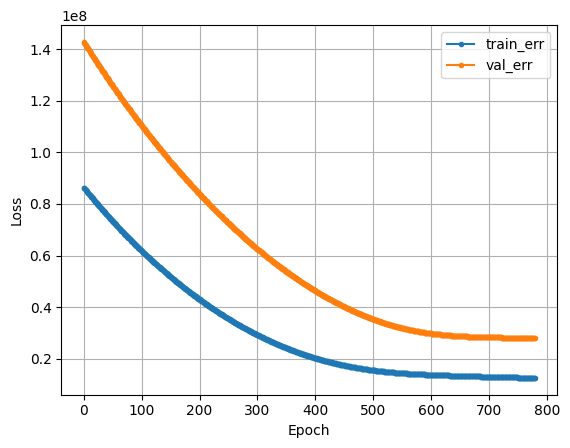

In [ ]:
dl_history_plot(history)

In [ ]:
y_pred1 = model1.predict(x_val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
print(root_mean_squared_error(y_val, y_pred1))
print(mean_absolute_error(y_val, y_pred1))
print(mean_absolute_percentage_error(y_val, y_pred1))
print(r2_score(y_val, y_pred1))

5304.577699905492
4121.253889973958
0.32581185749348707
-1.0542367206261134


In [ ]:
y_pred_test = model1.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
print(root_mean_squared_error(y_test, y_pred_test))
print(mean_absolute_error(y_test, y_pred_test))
print(mean_absolute_percentage_error(y_test, y_pred_test))
print(r2_score(y_test, y_pred_test))

6448.437887166209
5436.826102120535
0.4411655791056828
-1.290498698109412


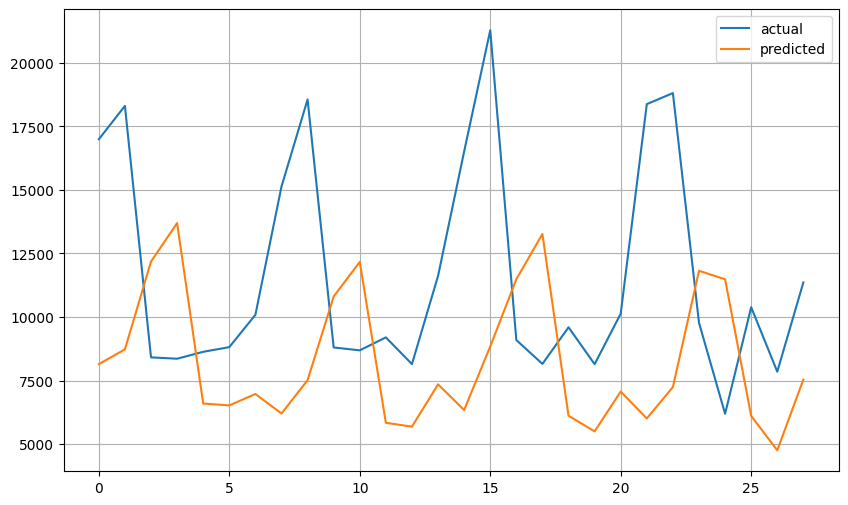

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(y_test[:100], label = 'actual')
plt.plot(y_pred_test[:100], label = 'predicted')
plt.legend()
plt.grid()
plt.show()

## **(2) 상품 : 12 - Milk**

### **1) 데이터 준비**

In [ ]:
def preproc(data, y_scale = False) :
    target = 'target'
    x = data.drop(['Date', target], axis = 1)
    y = data.loc[:, target]

    # 가변수화
    x['WeekDay'] = pd.Categorical(x['WeekDay'], categories = ['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday' ])
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['WeekDay','Month'])

    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)

    # y scale
    if y_scale == True :
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else :
        y_min, y_max = np.nan, np.nan

    # 분할
    x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 60, shuffle = False)

    return x_train, x_val, y_train, y_val, scaler, y_min, y_max

In [ ]:
def preproc12(data, y_scale=False):
    target = 'Target_Qty'
    x = data.drop(['Date', target], axis=1)
    y = data[target]

    # 가변수화
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['Month'])

    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)

    # y scale (0과 1 사이로 정규화)
    if y_scale:
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else:
        y_min, y_max = np.nan, np.nan

    # 데이터 분할 (훈련 세트, 검증 세트)
    x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=60, shuffle=False)

    return x_train, x_val, y_train, y_val, scaler, y_min, y_max


In [ ]:
x_train, x_val, y_train, y_val, scaler, y_min, y_max = preproc12(data_12, True)
x_train.shape, x_val.shape, y_train.shape, y_val.shape

((1084, 19), (60, 19), (1084,), (60,))

### **2) 모델링**

In [ ]:
# baseline model
model = Sequential()
model.add(Dense(1, input_shape=(x_train.shape[1],)))
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              20 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_val, y_val),).history

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1255 - val_loss: 0.0670
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0938 - val_loss: 0.0494
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0895 - val_loss: 0.0412
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0737 - val_loss: 0.0334
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0621 - val_loss: 0.0293
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0549 - val_loss: 0.0247
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0464 - val_loss: 0.0212
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0392 - val_loss: 0.0191
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0364 - val_loss: 0.0168
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0298 - val_loss: 0.0155
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0251 - val_loss: 0.0143
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0238 - val_lo

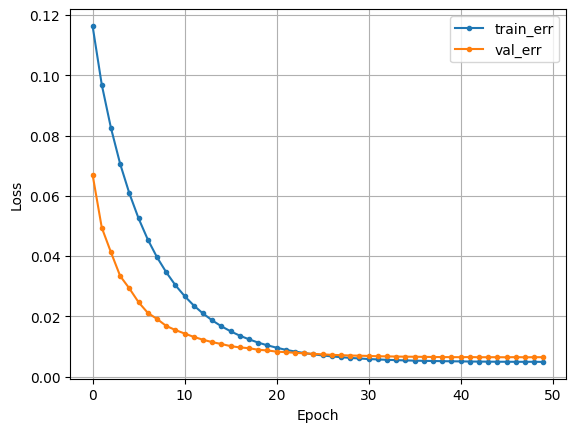

In [ ]:
dl_history_plot(history)

In [ ]:
# 스케일링 된 데이터 돌려서 평가하기
pred = model.predict(x_val)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
MAE :  2120.995076497396
MAPE :  9.678700326133869e+17
R2 :  0.2849247658388613


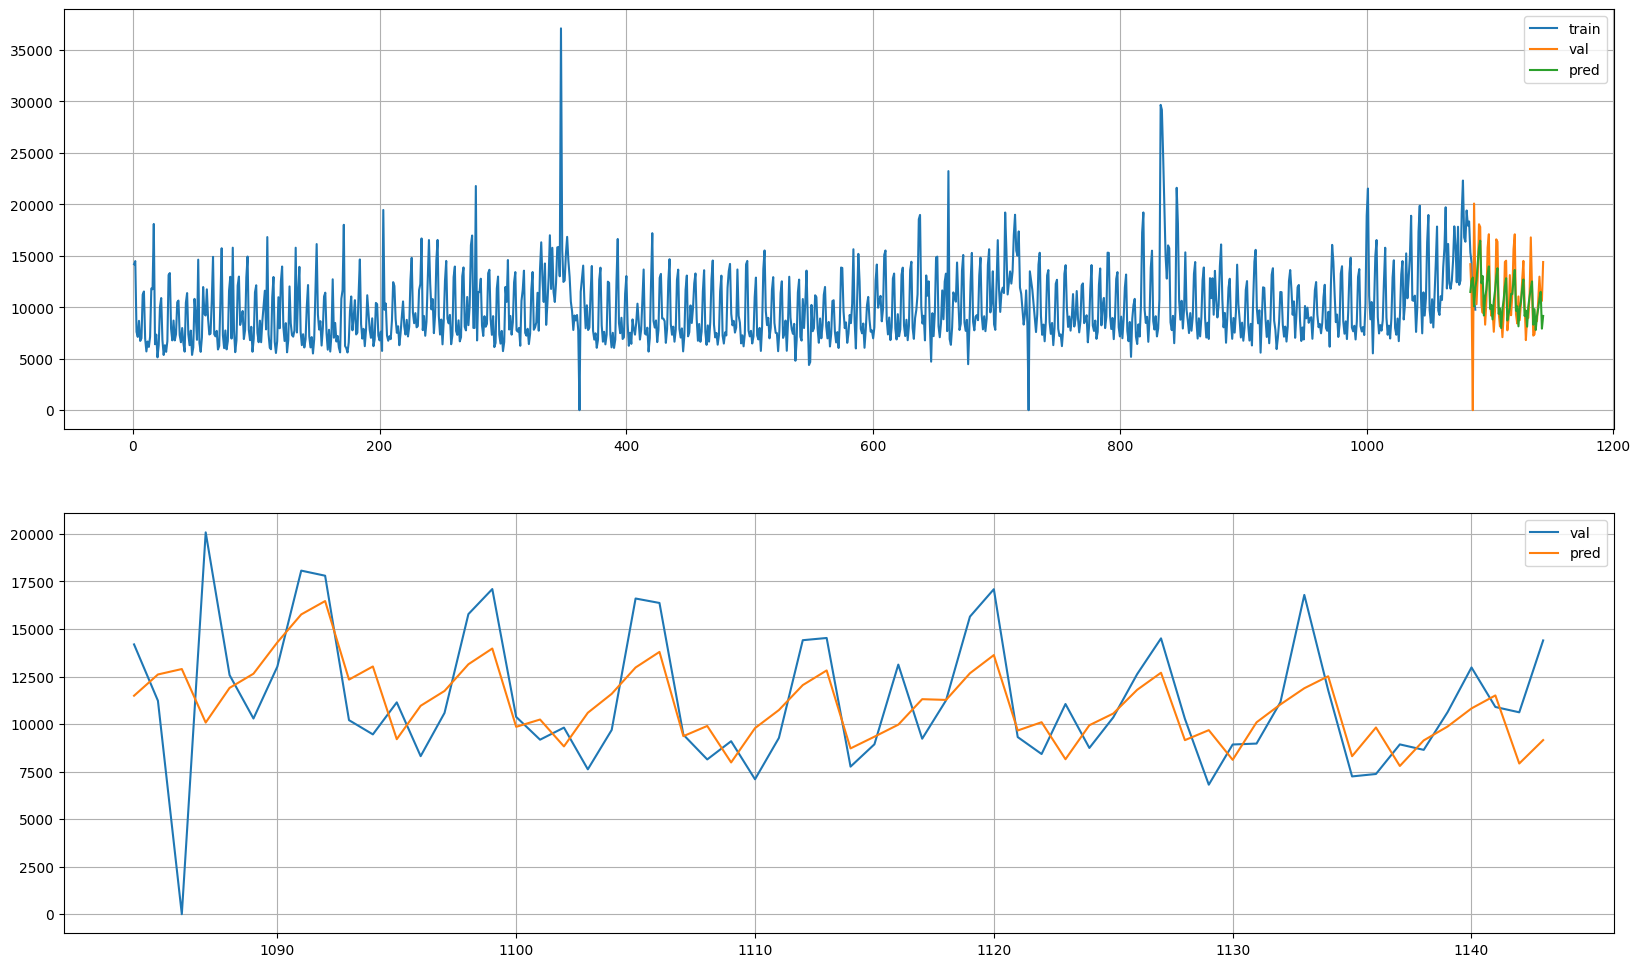

In [ ]:
y_train2 = y_train * (y_max - y_min) + y_min
plot_model_result(y_train2, y_val2, pred)

In [ ]:
from keras.callbacks import EarlyStopping

model = Sequential()
model.add(Dense(64, input_shape=(x_train.shape[1],), activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

model.compile(optimizer = Adam(learning_rate=0.001), loss='mse')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 64)                  │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,921 (70.00 KB)

 Trainable params: 17,921 (70.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train, y_train, epochs=1000, batch_size=32, validation_data=(x_val, y_val),callbacks=[es]).history

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0165 - val_loss: 0.0092
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0047 - val_loss: 0.0079
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0052 - val_loss: 0.0073
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056 - val_loss: 0.0069
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053 - val_loss: 0.0063
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0044 - val_loss: 0.0055
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0044 - val_loss: 0.0077
Epoch 8/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - val_loss: 0.0062
Epoch 9/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037 - val_loss: 0.0068
Epoch 10/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 - val_loss: 0.0087
Epoch 11/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028 - val_loss: 0.0074
Epoch 12/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

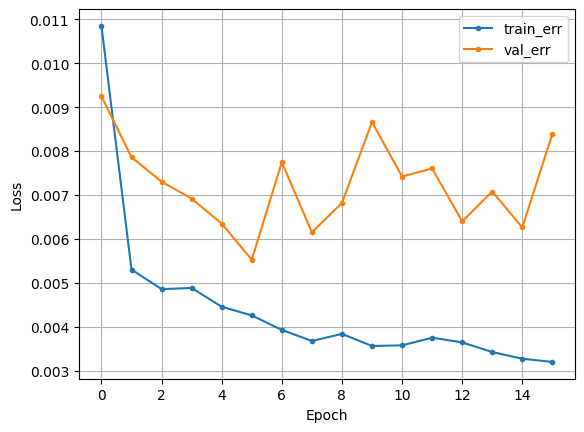

In [ ]:
dl_history_plot(history)

In [ ]:
# 스케일링 된 데이터 돌려서 평가하기
pred = model.predict(x_val)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
MAE :  1818.693408203125
MAPE :  1.0331157856133667e+18
R2 :  0.38546770213558257


## **(3) 상품 : 42 - Agricultural products**

### **1) 데이터 준비**

In [ ]:
target = '2days_later_Qty'
x = df.drop(columns = target)
y = df.loc[:, target]

In [ ]:
# 데이터셋 분할
x_train, x_val = x[:-60], x[-60:]
y_train, y_val = y[:-60], y[-60:]

In [ ]:

print(x_train.shape)
print(x_val.shape)
print(y_train.shape)
print( y_val.shape)

(1086, 3)
(60, 3)
(1086,)
(60,)


In [ ]:
n_feature = x_train.shape[1]
n_feature

3

### **2) 모델링**

In [ ]:
# baseline : model1
clear_session()

model1 = Sequential([Input(shape=(n_feature,)),
                     Dense(1)])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(loss = 'mse', optimizer = Adam(learning_rate = 0.001))

In [ ]:
history1 = model1.fit(x_train, y_train, epochs=50, validation_split=0.1).history

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5121 - val_loss: 0.4874
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4204 - val_loss: 0.3978
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3457 - val_loss: 0.3221
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2802 - val_loss: 0.2587
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2285 - val_loss: 0.2064
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1732 - val_loss: 0.1638
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1443 - val_loss: 0.1289
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1120 - val_loss: 0.1015
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0854 - val_loss: 0.0799
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0693 - val_loss: 0.0632
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0550 - val_loss: 0.0506
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0440 - val_lo

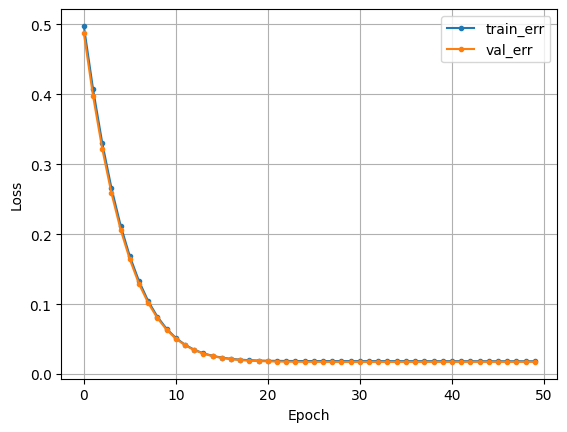

In [ ]:
dl_history_plot(history1)

In [ ]:
pred1 = model1.predict(x_val)
print('MAE :', mean_absolute_error(y_val,pred1))
print('MAPE :', mean_absolute_percentage_error(y_val,pred1))
print('R2_score : ', r2_score(y_val, pred1))

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
MAE : 0.09885880237909868
MAPE : 0.49213790274768227
R2_score :  -0.28213139108201957


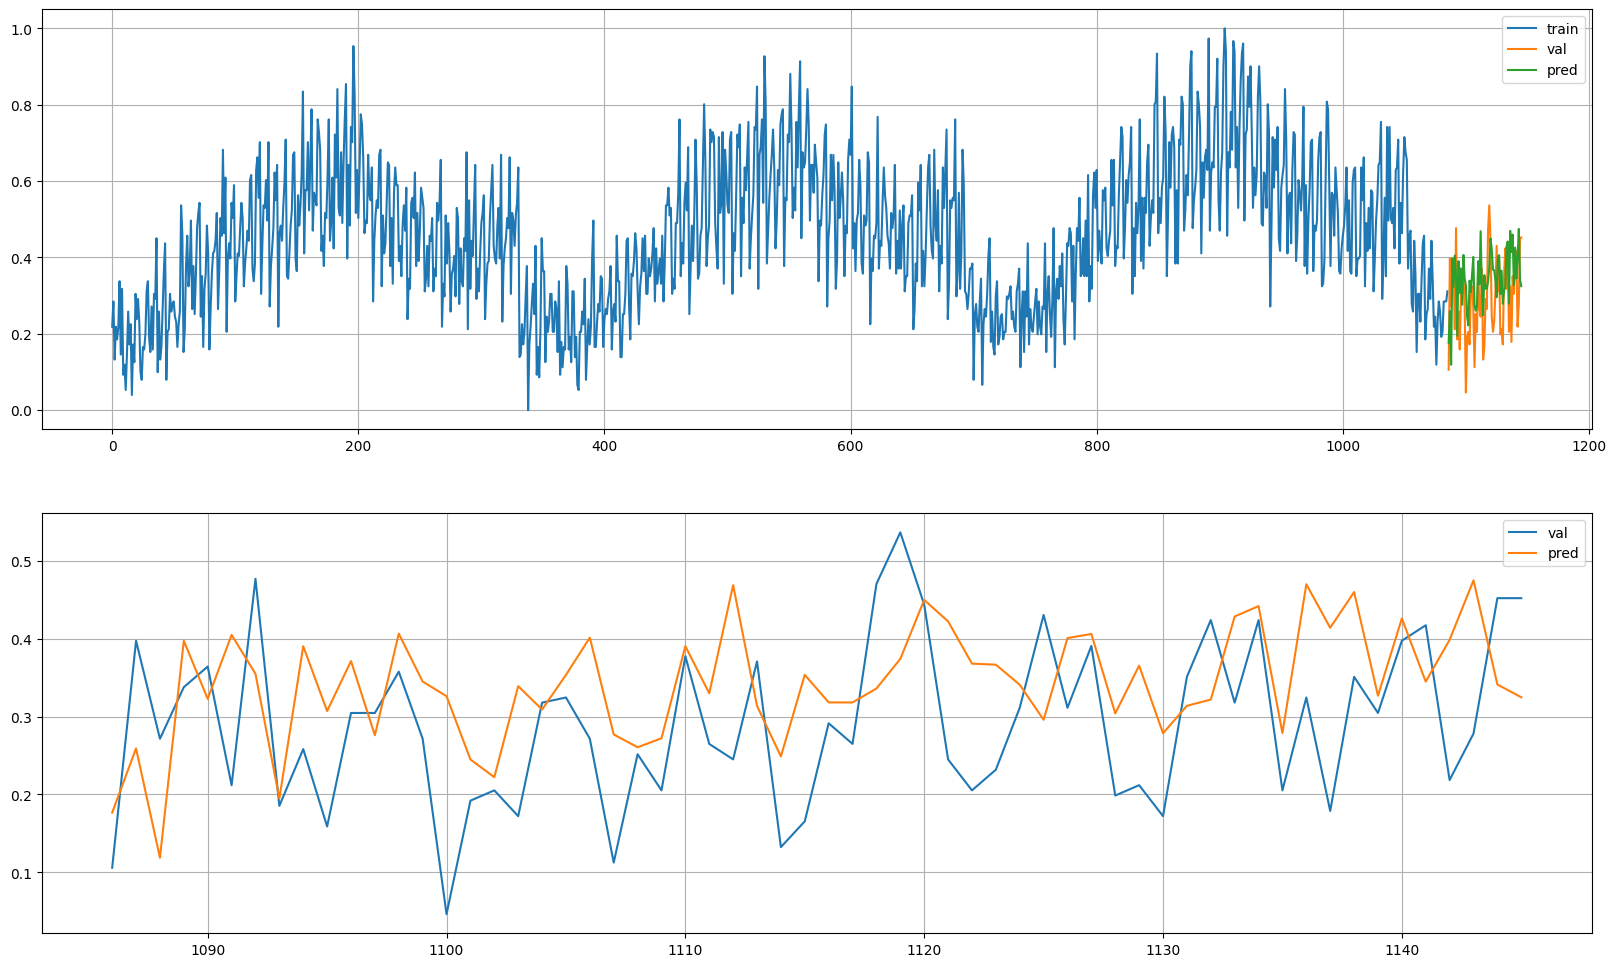

In [ ]:
plot_model_result(y_train, y_val, pred1)

In [ ]:
#농산물 모델링2
st_df['target'] = st_df['Qty'].shift(-2)
st_df.dropna(inplace = True)
st_df.head()

,Date,Qty,WTI_Price,CustomerCount,meat_Qty,WeekDay,Month,target
0,2014-01-02,76.0,95.140000,4422,981.64400,Thursday,1,78.0
1,2014-01-03,74.0,93.660000,4167,1278.90810,Friday,1,88.0
2,2014-01-04,78.0,93.436815,5341,1398.66600,Saturday,1,65.0
3,2014-01-05,88.0,93.167006,5123,1119.53500,Sunday,1,78.0
4,2014-01-06,65.0,93.120000,3917,526.12897,Monday,1,73.0


In [ ]:
x_train_h, x_val_h, y_train_h, y_val_h, scaler_h, y_min, y_max = preproc(st_df, True)
y_min, y_max

(45.0, 196.0)

In [ ]:
nfeatures = x_train_h.shape
nfeatures

(1026, 23)

In [ ]:
clear_session()
nfeatures = x_train_h.shape[1]
base_model =Sequential([Dense(1, input_shape = (nfeatures, ) )])
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              24 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24 (96.00 B)

 Trainable params: 24 (96.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
base_model.compile(optimizer = 'adam', loss = 'mse')
base_history = base_model.fit(x_train_h, y_train_h, epochs = 50, validation_split = .2, verbose = 0).history

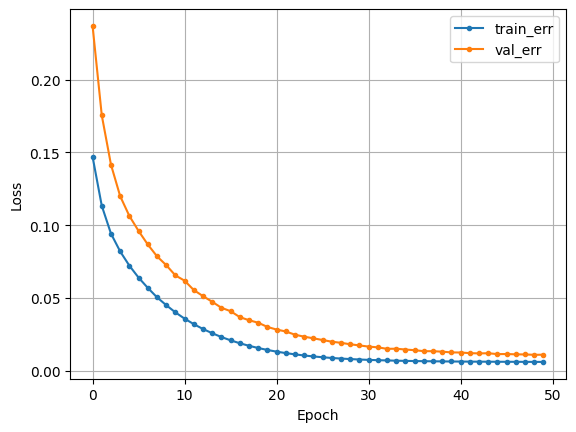

In [ ]:
dl_history_plot(base_history)

In [ ]:
pred = base_model.predict(x_val_h)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val_h * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
MAE :  13.851708221435548
MAPE :  0.13574352768635453
R2 :  0.5680235414466681


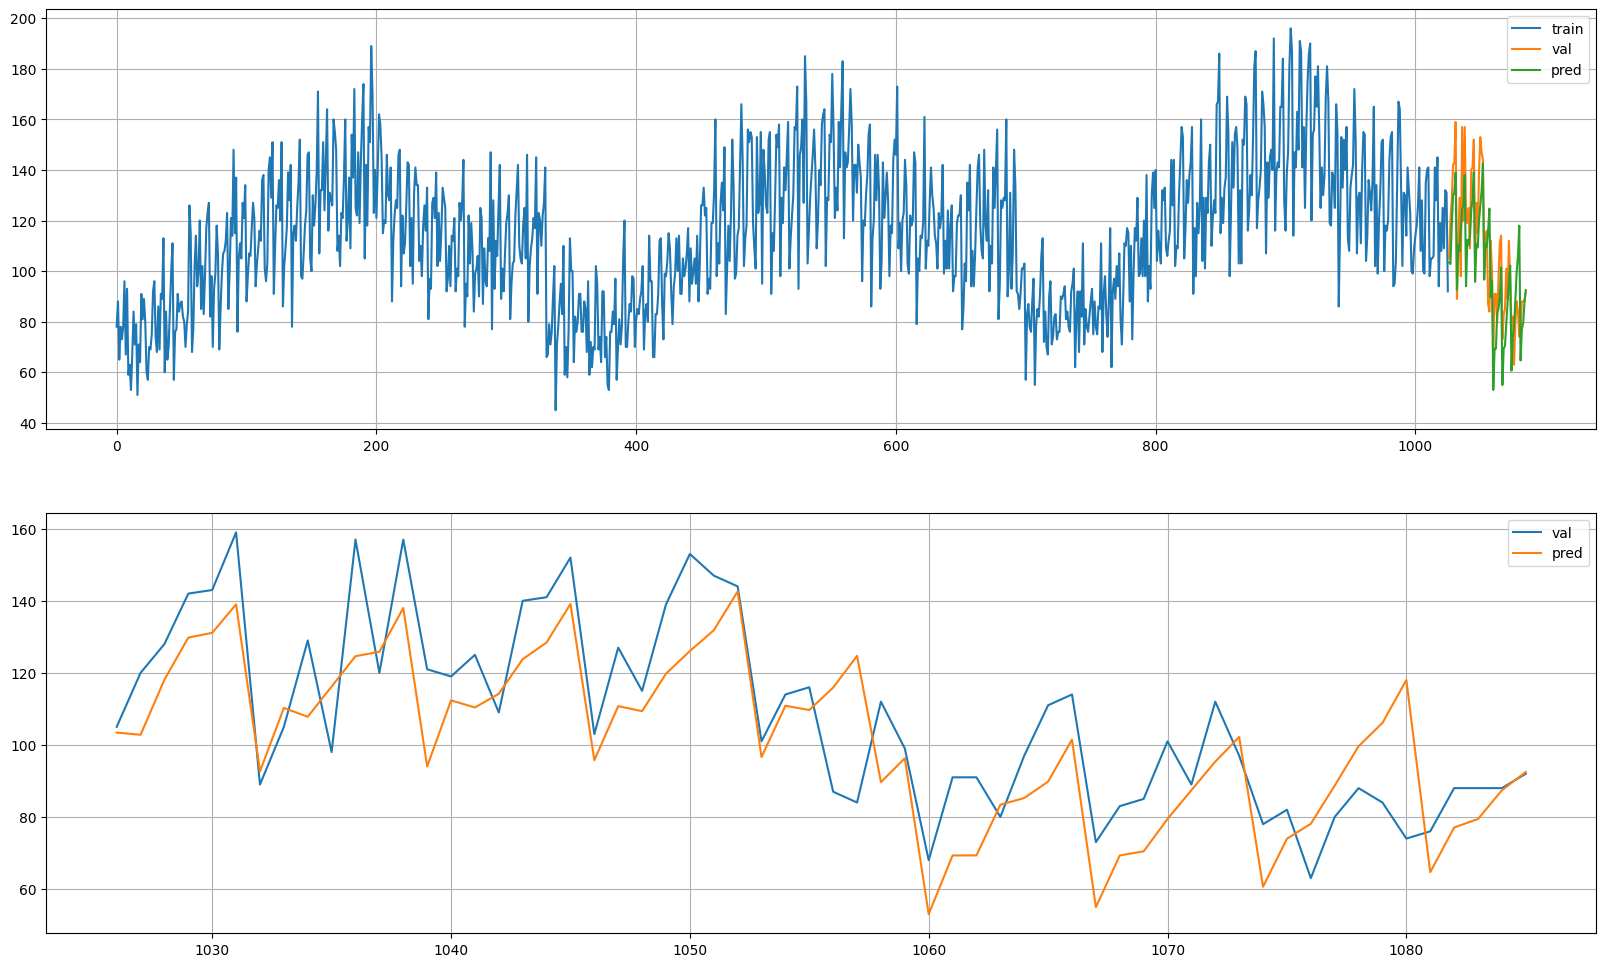

In [ ]:
y_train2 = y_train_h * (y_max - y_min) + y_min
plot_model_result(y_train2, y_val2, pred)

# **4.LSTM, CNN 초기 모델**

* **세부 요구사항**
    * 3차원 데이터 구조 만들기
        * timestep 수는 적절한 간격으로 한가지 경우만 지정을 합니다.
    * LSTM, CNN 기반 초기 모델 생성
        * 성능 보다는 코드 틀을 작성하는데 집중합시다.
        * 노드 혹은 필터 수와 크기는 초기값으로 적절하게 지정해 봅시다.

In [ ]:
def temporalize(x, y, timesteps):
    output_X = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        output_X.append(x.iloc[i:i+timesteps])
        output_y.append(y.iloc[i+timesteps-1])
    return np.array(output_X), np.array(output_y)

In [ ]:
df

,Qty,CustomerCount,7days_before_Qty,2days_later_Qty
0,0.205298,0.326893,0.452436,0.218543
1,0.192053,0.283296,0.452436,0.284768
2,0.218543,0.484014,0.452436,0.132450
3,0.284768,0.446743,0.452436,0.218543
4,0.132450,0.240554,0.452436,0.185430
...,...,...,...,...
1141,0.304636,0.348607,0.423841,0.417219
1142,0.397351,0.360574,0.317881,0.218543
1143,0.417219,0.233715,0.423841,0.278146
1144,0.218543,0.248077,0.205298,0.451987


## **(1) LSTM 초기 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

In [ ]:

y_2 = total['2d_later']
x_2 = total.drop(columns=['2d_later'])

scaler = MinMaxScaler()
x_2_scaled = scaler.fit_transform(x_2)  # x만 스케일링

x_2_scaled = pd.DataFrame(x_2_scaled, columns=x_2.columns)

x_2_scaled,y=temporalize(x_2_scaled,y_2,60)

y=scaler.fit_transform(y.reshape(-1,1))
x_2_test, y_2_test = x_2_scaled[-60:], y[-60:]
x_2_train, y_2_train = x_2_scaled[:-60], y[:-60]


x_2_train, x_2_val, y_2_train, y_2_val = train_test_split(x_2_train, y_2_train, test_size=0.2)


print("x_train shape:", x_2_train.shape)
print("x_val shape:", x_2_val.shape)
print("x_test shape:", x_2_test.shape)


x_train shape: (824, 60, 13)
x_val shape: (206, 60, 13)
x_test shape: (60, 60, 13)


In [ ]:
x = df_bev.drop(columns=['Date', 'y'])
y = df_bev['y']
timesteps = 7

x, y = temporalize(x, y, timesteps)

In [ ]:
x[0]

array([[4422.0, 9853.0, 95.14, 3, 1, False, False, False, False, False,
        False, False, True, False, 1302.47, 41.0, 2991.0],
       [4167.0, 8647.0, 93.66, 4, 1, False, False, False, False, False,
        False, False, True, False, 1243.054, 40.0, 2694.0],
       [5341.0, 15153.0, 93.48, 5, 1, False, False, False, False, False,
        False, False, True, False, 1882.78, 90.0, 4355.0],
       [5123.0, 15606.0, 93.3, 6, 1, False, False, False, False, False,
        False, False, True, False, 2029.317, 96.0, 4228.0],
       [3917.0, 7900.0, 93.12, 0, 1, False, False, False, False, False,
        False, False, True, False, 992.359, 33.0, 2323.0],
       [3663.0, 7188.0, 93.31, 1, 1, False, False, False, False, False,
        False, False, True, False, 933.215, 44.0, 2147.0],
       [4254.0, 8800.0, 91.9, 2, 1, False, False, False, False, False,
        False, False, True, False, 1250.435, 68.0, 2618.0]], dtype=object)

In [ ]:
num_samples = x.shape[0]
num_features = 2  # 수치 데이터가 포함된 첫 번째와 두 번째 열만 고려

# 3차원 배열을 2차원으로 펼치기
numeric_data = x[:, :, :num_features].reshape(-1, num_features).astype(float)

# MinMaxScaler를 사용하여 수치 데이터 스케일링
scaler = MinMaxScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)

# 스케일링된 데이터를 원래 형태로 복원
scaled_numeric_data = scaled_numeric_data.reshape(num_samples, timesteps, num_features)

# 불리언 데이터를 선택
other_data = x[:, :, num_features:]

# 수치 데이터와 불리언 데이터를 다시 결합
x = np.concatenate((scaled_numeric_data, other_data), axis=2)

x[0]

array([[0.32689348606599417, 0.31028368794326244, 95.14, 3, 1, False,
        False, False, False, False, False, False, True, False, 1302.47,
        41.0, 2991.0],
       [0.28329628996409645, 0.2568262411347518, 93.66, 4, 1, False,
        False, False, False, False, False, False, True, False, 1243.054,
        40.0, 2694.0],
       [0.48401436142930415, 0.5452127659574468, 93.48, 5, 1, False,
        False, False, False, False, False, False, True, False, 1882.78,
        90.0, 4355.0],
       [0.44674303299709356, 0.5652925531914894, 93.3, 6, 1, False,
        False, False, False, False, False, False, True, False, 2029.317,
        96.0, 4228.0],
       [0.24055394084458886, 0.2237145390070922, 93.12, 0, 1, False,
        False, False, False, False, False, False, True, False, 992.359,
        33.0, 2323.0],
       [0.19712771413916913, 0.19215425531914893, 93.31, 1, 1, False,
        False, False, False, False, False, False, True, False, 933.215,
        44.0, 2147.0],
       [0.298

In [ ]:
x_train = x[:-60]
x_val = x[-60:]
y_train = y[:-60]
y_val = y[-60:]

In [ ]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1078, 7, 17), (1078,), (60, 7, 17), (60,))

In [ ]:
x_train = x_train.astype(np.float32)
y_train = y_train.astype(np.float32)
x_val = x_val.astype(np.float32)
y_val = y_val.astype(np.float32)

In [ ]:
x_test = df_bev_test.drop(columns=['Date', 'y'])
y_test = df_bev_test['y']

x_test, y_test = temporalize(x_test, y_test, timesteps)

In [ ]:
num_samples = x_test.shape[0]
num_features = 2  # 수치 데이터가 포함된 첫 번째와 두 번째 열만 고려

# 3차원 배열을 2차원으로 펼치기
numeric_data = x_test[:, :, :num_features].reshape(-1, num_features).astype(float)

# MinMaxScaler를 사용하여 수치 데이터 스케일링
scaler = MinMaxScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)

# 스케일링된 데이터를 원래 형태로 복원
scaled_numeric_data = scaled_numeric_data.reshape(num_samples, timesteps, num_features)

# 불리언 데이터를 선택
other_data = x_test[:, :, num_features:]

# 수치 데이터와 불리언 데이터를 다시 결합
x_test = np.concatenate((scaled_numeric_data, other_data), axis=2)

x_test[0]

array([[0.3296610169491525, 0.18053437645030823, 52.63, 3, 3, False,
        False, False, True, False, False, False, False, False, 1407.037,
        51.0, 2234.0],
       [0.5843220338983051, 0.26930981900152484, 53.33, 4, 3, False,
        False, False, True, False, False, False, False, False, 1710.55,
        29.0, 2888.0],
       [0.9652542372881354, 0.7157727242590995, 53.28333333333333, 5, 3,
        False, False, False, True, False, False, False, False, False,
        2430.925, 53.0, 4317.0],
       [0.9826271186440676, 0.8028243718093216, 53.236666666666665, 6, 3,
        False, False, False, True, False, False, False, False, False,
        2742.407, 74.0, 4579.0],
       [0.3296610169491525, 0.1470529735463767, 53.19, 0, 3, False,
        False, False, True, False, False, False, False, False, 1400.493,
        28.0, 2333.0],
       [0.3067796610169491, 0.14353908373665714, 52.68, 1, 3, False,
        False, False, True, False, False, False, False, False, 1230.641,
        27.0

In [ ]:
x_test = x_test.astype(np.float32)
y_test = y_test.astype(np.float32)

* **모델링**

In [ ]:


clear_session()

model2 = Sequential()
model2.add(LSTM(4, input_shape=(x_2_train.shape[1], x_2_train.shape[2]), return_sequences=True))

# 출력층
model2.add(Dense(1))

model2.compile(loss='mse', optimizer='adam', metrics=['mse'])
model2.summary()

hist2 = model2.fit(x_2_train, y_2_train, epochs=300, batch_size=64, validation_data=(x_2_val, y_2_val), callbacks=[es]).history


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 4)               │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 60, 1)               │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 293 (1.14 KB)

 Trainable params: 293 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300


KeyboardInterrupt: 

In [ ]:
pred3=model3.predict(x_2_test)
pred2=pred2[-1]
pred2=scaler.inverse_transform(pred2)
y_s=scaler.inverse_transform(y_2_test)
pred2=pd.DataFrame(pred2)



In [ ]:
#y_test,pred=y_2_test.reset_index(drop=True),pred2.reset_index(drop=True)
plt.figure(figsize=(20,10))
plt.plot(y_s,label='y_test')
plt.plot(pred3,label='pred')
plt.legend()
plt.show()

------------------------------------------------------------------

In [ ]:
timestep = x_train.shape[1]
nfeatures = x_train.shape[2]

In [ ]:
from keras.callbacks import EarlyStopping

model2 = Sequential([Input(shape=(timestep, nfeatures)),
                     LSTM(8, return_sequences=True),
                     Flatten(),
                     Dense(1)])

model2.compile(optimizer=Adam(0.1), loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', min_delta=0, patience=20, restore_best_weights=True)

history = model2.fit(x_train, y_train, epochs=1000, validation_data=[x_val, y_val], callbacks=[es]).history

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 87970000.0000 - mae: 8702.4971 - val_loss: 142613360.0000 - val_mae: 11354.0977
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 86470008.0000 - mae: 8561.4980 - val_loss: 142019552.0000 - val_mae: 11327.9189
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 83975472.0000 - mae: 8490.4541 - val_loss: 141426592.0000 - val_mae: 11301.7168
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 83238336.0000 - mae: 8421.3711 - val_loss: 140836352.0000 - val_mae: 11275.5732
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 87740896.0000 - mae: 8625.4072 - val_loss: 140250048.0000 - val_mae: 11249.5439
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 81249328.0000 - mae: 8325.8096 - val_loss: 139668352.0000 - val_mae: 11223.6592
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 80934176.0000 - mae: 8294.6826 - val_loss: 139086128.0000 - val_mae: 11197.6924
Epoch 8/1000
34/34 

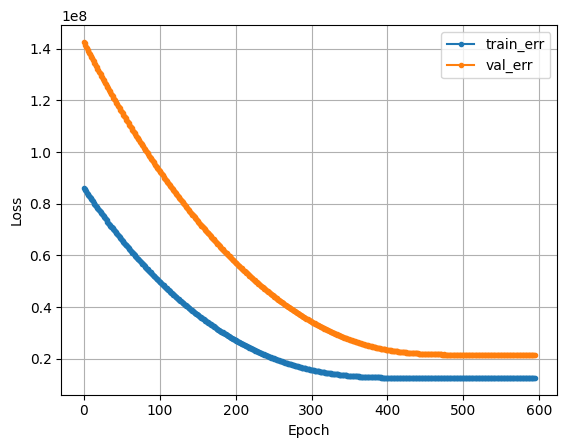

In [ ]:
dl_history_plot(history)

In [ ]:
y_pred2 = model2.predict(x_val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


In [ ]:
print(root_mean_squared_error(y_val, y_pred2))
print(mean_absolute_error(y_val, y_pred2))
print(mean_absolute_percentage_error(y_val, y_pred2))
print(r2_score(y_val, y_pred2))

4635.3574
3237.0898
0.23493944
-0.5686111450195312


In [ ]:
y_pred_test2 = model2.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [ ]:
print(root_mean_squared_error(y_test, y_pred_test2))
print(mean_absolute_error(y_test, y_pred_test2))
print(mean_absolute_percentage_error(y_test, y_pred_test2))
print(r2_score(y_test, y_pred_test2))

5224.933
3446.4338
0.23297296
-0.5124971866607666


In [ ]:
y_pred_test2[:10]

array([[8589.788],
       [8589.788],
       [8589.788],
       [8589.788],
       [8589.788],
       [8589.788],
       [8589.788],
       [8589.788],
       [8589.788],
       [8589.788]], dtype=float32)

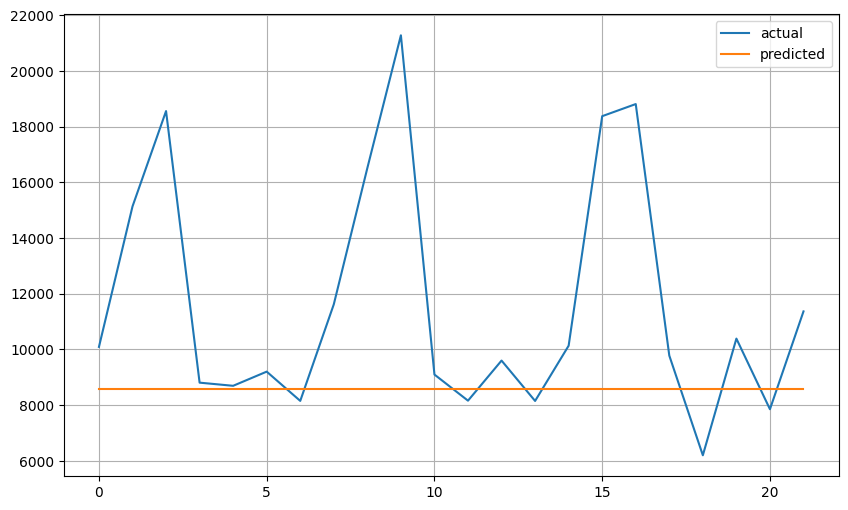

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(y_test[:100], label = 'actual')
plt.plot(y_pred_test2[:100], label = 'predicted')
plt.legend()
plt.grid()
plt.show()

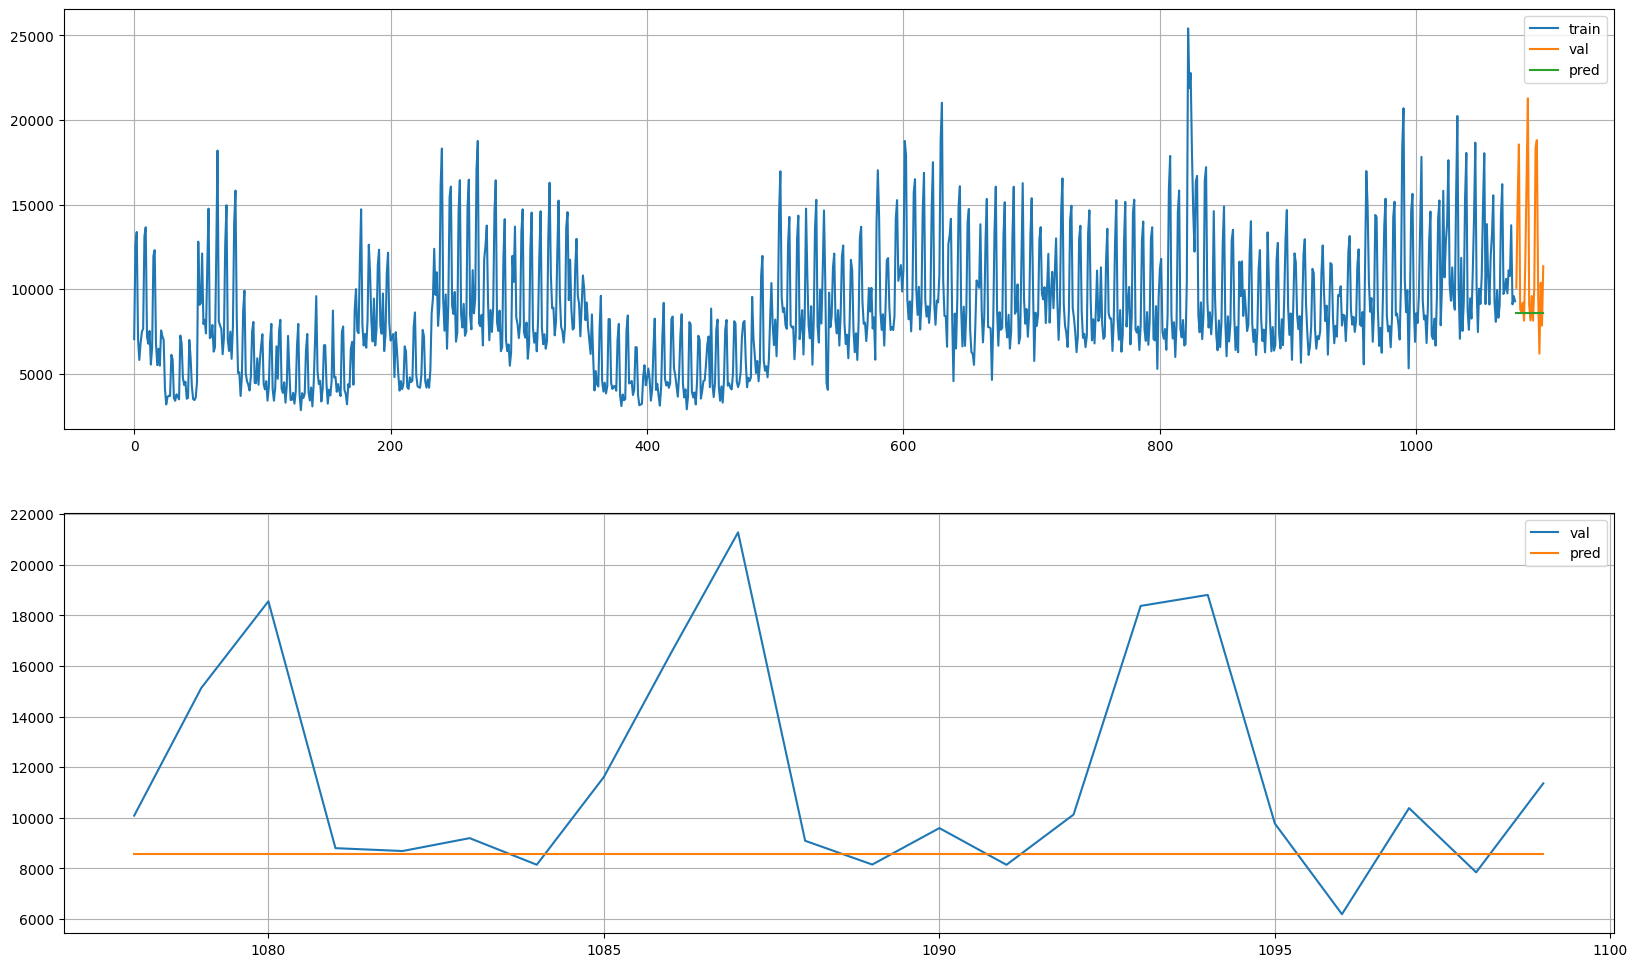

In [ ]:
plot_model_result(y_train, y_test, y_pred_test2)

### **2) 상품 : 12 - Milk**

* **데이터 준비**

In [ ]:
def preproc3d12(data, timesteps, y_scale = False) :
    target = 'Target_Qty'
    x = data.drop(['Date', target], axis=1)
    y = data[target]

    # 가변수화 (범주형 변수 처리)
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['Month'])
    col_names = list(x)

    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)
    x = pd.DataFrame(x, columns=col_names)

    # y scale (0과 1 사이로 정규화)
    if y_scale:
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else:
        y_min, y_max = np.nan, np.nan

    # 3차원 변환
    x3, y3 = temporalize(x, y, timesteps)

    # 데이터 분할 (훈련 세트, 검증 세트)
    x_train, x_val, y_train, y_val = train_test_split(x3, y3, test_size=60, shuffle=False)

    return x_train, x_val, y_train, y_val, scaler, y_min, y_max

In [ ]:
timesteps = 7
x_train12, x_val12, y_train12, y_val12, scaler, y_min, y_max = preproc3d12(data_12, timesteps, True)
y_min, y_max, x_train.shape, x_val.shape

(0.0, 37106.0, (1086, 3), (60, 3))

In [ ]:
clear_session()

_, ts, nfeat = x_train12.shape

model12_01 = Sequential([LSTM(500, input_shape = (ts, nfeat) ),
                         Dense(1)])
model12_01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 500)                 │       1,040,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             501 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,040,501 (3.97 MB)

 Trainable params: 1,040,501 (3.97 MB)

 Non-trainable params: 0 (0.00 B)

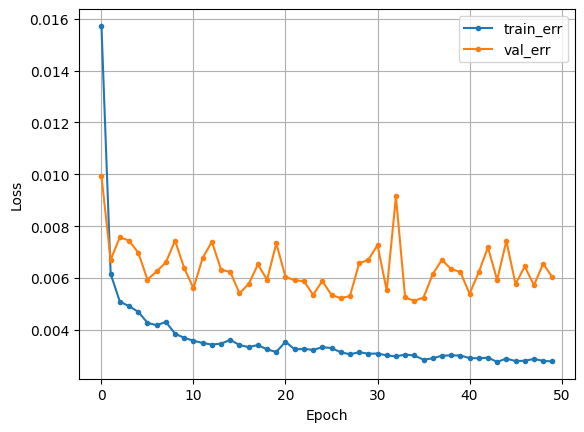

In [ ]:
model12_01.compile(optimizer = 'adam', loss = 'mse')
hist = model12_01.fit(x_train12, y_train12, epochs = 50, validation_data=(x_val12, y_val12), verbose = 0).history
dl_history_plot(hist)

In [ ]:
# 스케일링 된 데이터 돌려서 평가하기
pred = model12_01.predict(x_val12)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val12 * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
MAE :  2047.4429361979167
MAPE :  8.36964817038283e+17
R2 :  0.32987376568984617


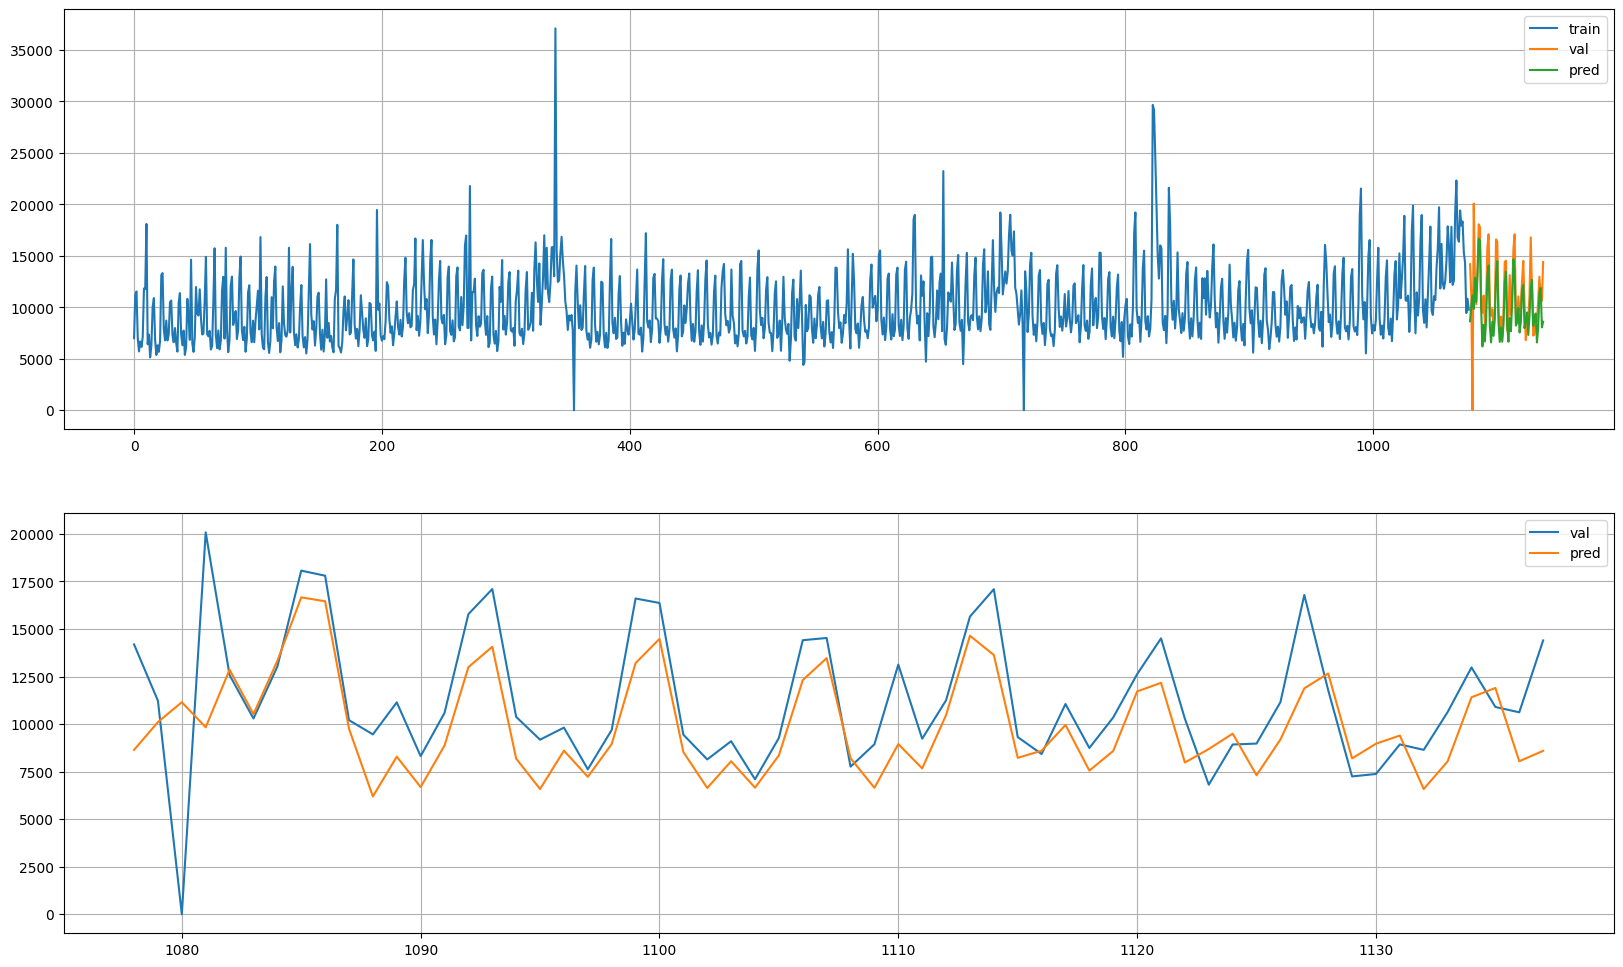

In [ ]:
y_train2 = y_train12 * (y_max - y_min) + y_min
plot_model_result(y_train2, y_val2, pred)

* **모델링**

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

In [ ]:
timesteps = 7
x_train, y_train = temporalize(x_train, y_train, timesteps)
x_val, y_val = temporalize(x_val, y_val, timesteps)

In [ ]:
print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

x_train shape: (1080, 7, 3)
x_val shape: (54, 7, 3)
y_train shape: (1080,)
y_val shape: (54,)


* **모델링**

In [ ]:
clear_session()

model2 = Sequential([LSTM(10,input_shape = (timesteps, n_feature), return_sequences=False),
                     Dense(1)])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10)                  │             560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 571 (2.23 KB)

 Trainable params: 571 (2.23 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 모델 컴파일
model2.compile(optimizer=Adam(learning_rate = 0.001), loss='mae')

In [ ]:
history2 = model2.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2).history

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.3370 - val_loss: 0.1456
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1235 - val_loss: 0.1470
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1121 - val_loss: 0.1311
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1082 - val_loss: 0.1254
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1040 - val_loss: 0.1203
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1005 - val_loss: 0.1146
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0961 - val_loss: 0.1146
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0956 - val_loss: 0.1100
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0985 - val_loss: 0.1083
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0920 - val_loss: 0.1079
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0938 - val_loss: 0.1073
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0918 - val_l

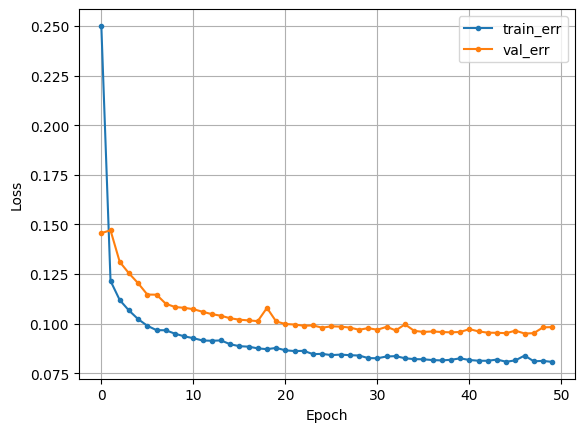

In [ ]:
dl_history_plot(history2)

In [ ]:
pred2 = model2.predict(x_val)
print('MAE :', mean_absolute_error(y_val,pred2))
print('MAPE :', mean_absolute_percentage_error(y_val,pred2))
print('R2_score : ', r2_score(y_val, pred2))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
MAE : 0.06713485234956809
MAPE : 0.31345695685323677
R2_score :  0.29482258181692156


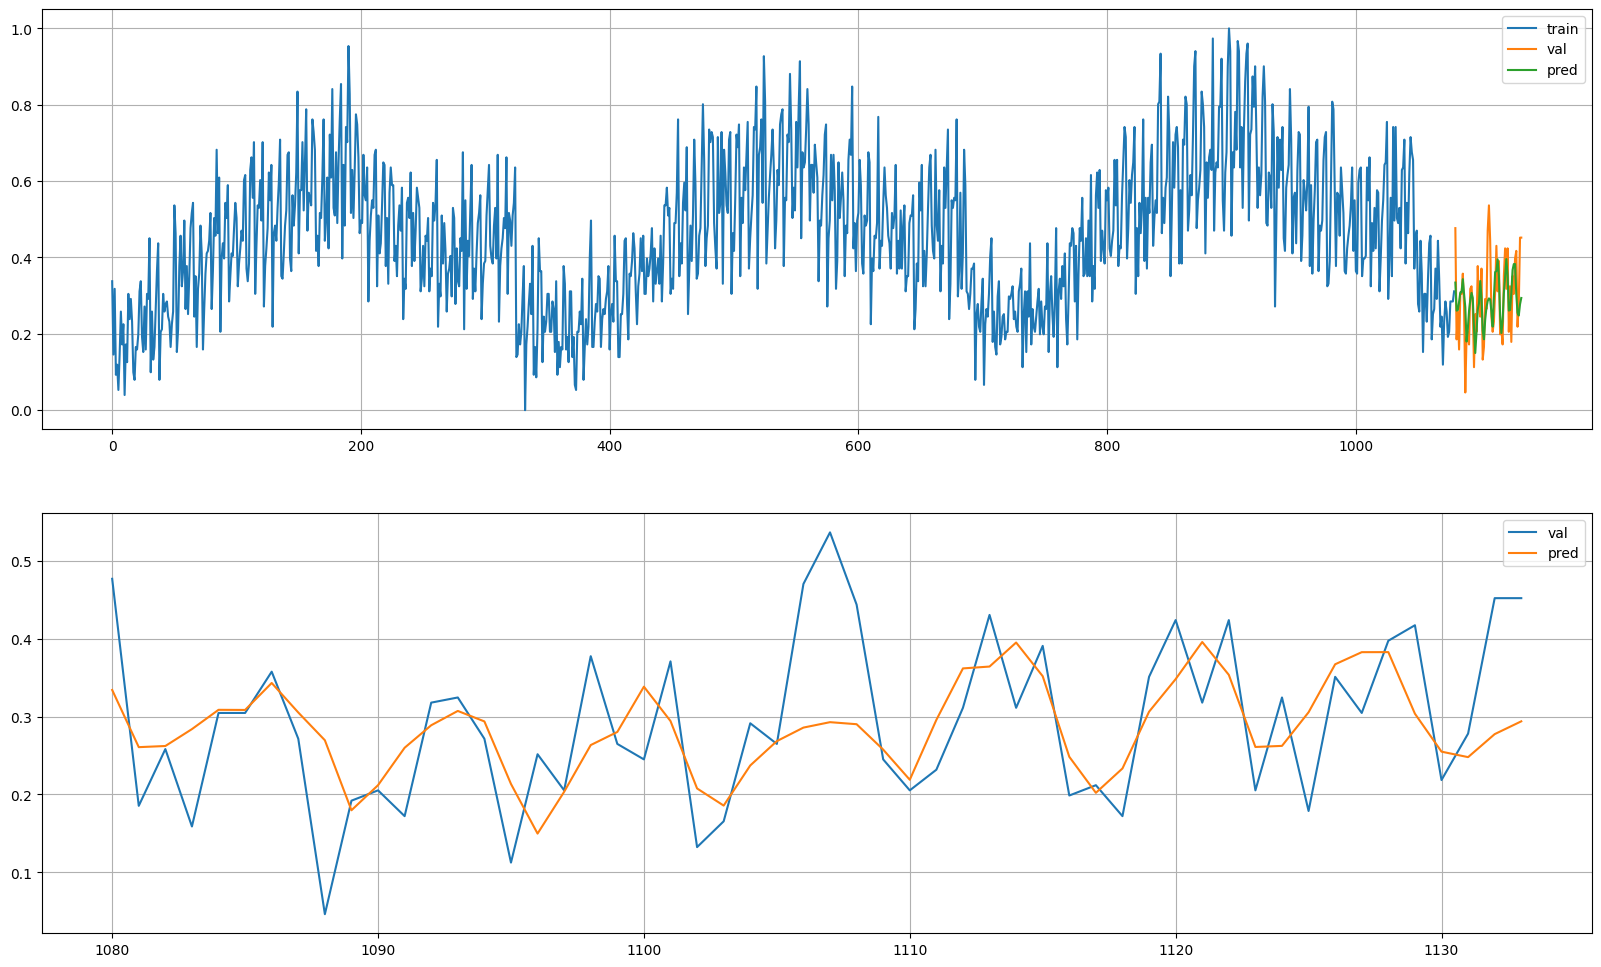

In [ ]:
plot_model_result(y_train, y_val, pred2)

In [ ]:
#농산물 모델링2
def temporalize(x, y, timesteps):
    output_X = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        output_X.append(x.iloc[i:i+timesteps])
        output_y.append(y.iloc[i+timesteps-1])
    return np.array(output_X), np.array(output_y)

In [ ]:
def preproc3d(data, timesteps, y_scale = False) :
    target = 'target'
    x = data.drop(['Date', target], axis = 1)
    y = data.loc[:, target]

    # 가변수화
    x['WeekDay'] = pd.Categorical(x['WeekDay'], categories = ['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday' ])
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['WeekDay','Month'])
    col_names = list(x)


    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)
    x = pd.DataFrame(x, columns=col_names)

    # y scale
    if y_scale == True :
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else :
        y_min, y_max = np.nan, np.nan

    # 3차원 변환
    x3, y3 = temporalize(x, y, timesteps)

    # 분할
    x_train, x_val, y_train, y_val = train_test_split(x3, y3, test_size = 120, shuffle = False)

    return x_train, x_val, y_train, y_val, scaler, y_min, y_max

In [ ]:
timesteps = 7
x_train_h, x_va_l_h, y_train_h, y_val_h, scaler_h, y_min, y_max = preproc3d(st_df, timesteps, True)
y_min, y_max, x_train_h.shape, x_val_h.shape

(45.0, 196.0, (960, 7, 23), (60, 23))

In [ ]:
from keras.layers import Dropout
clear_session()

_, ts, nfeat = x_train_h.shape

LSTM_model = Sequential([LSTM(4, input_shape = (ts, nfeat), return_sequences=True ),
                        LSTM(8, return_sequences=True),
                        LSTM(16, return_sequences=True),
                        LSTM(32, return_sequences=True),
                        LSTM(64, return_sequences=True),
                        LSTM(32, return_sequences=True),
                        LSTM(16, return_sequences=True),
                        LSTM(8, return_sequences=True),
                        LSTM(4,),
                        Dense(1)
                         ])
LSTM_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 7, 4)                │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 7, 8)                │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 7, 16)               │           1,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 7, 32)               │           6,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 7, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 7, 32)               │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 7, 16)               │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 7, 8)                │             800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 4)                   │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,133 (195.83 KB)

 Trainable params: 50,133 (195.83 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step - loss: 0.1688 - val_loss: 0.0636
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0355 - val_loss: 0.0656
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0305 - val_loss: 0.0536
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0294 - val_loss: 0.0566
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0304 - val_loss: 0.0522
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0259 - val_loss: 0.0282
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0135 - val_loss: 0.0276
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0108 - val_loss: 0.0245
Epoch 9/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0108 - val_loss: 0.0218
Epoch 10/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0096 - val_loss: 0.0174
Epoch 11/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0091 - val_loss: 0.0140
Epoch 12/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/ste

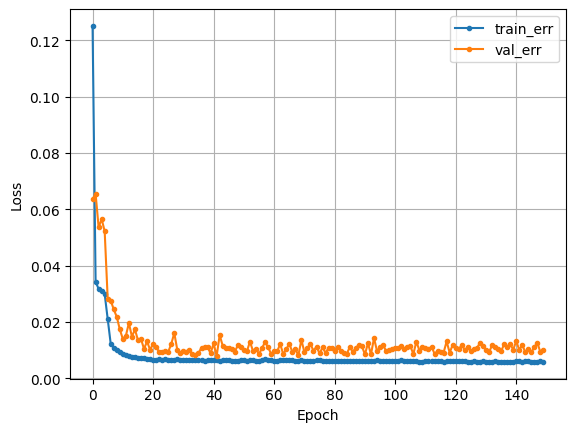

In [ ]:
LSTM_model.compile(optimizer = 'adam', loss = 'mse')
LSTM_hist = LSTM_model.fit(x_train_h, y_train_h, epochs = 150, validation_split = .2).history
dl_history_plot(LSTM_hist)

In [ ]:
pred = LSTM_model.predict(x_va_l_h)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val_h * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 519ms/step
MAE :  12.00479825337728
MAPE :  0.10410683179454562
R2 :  0.6027752309239802


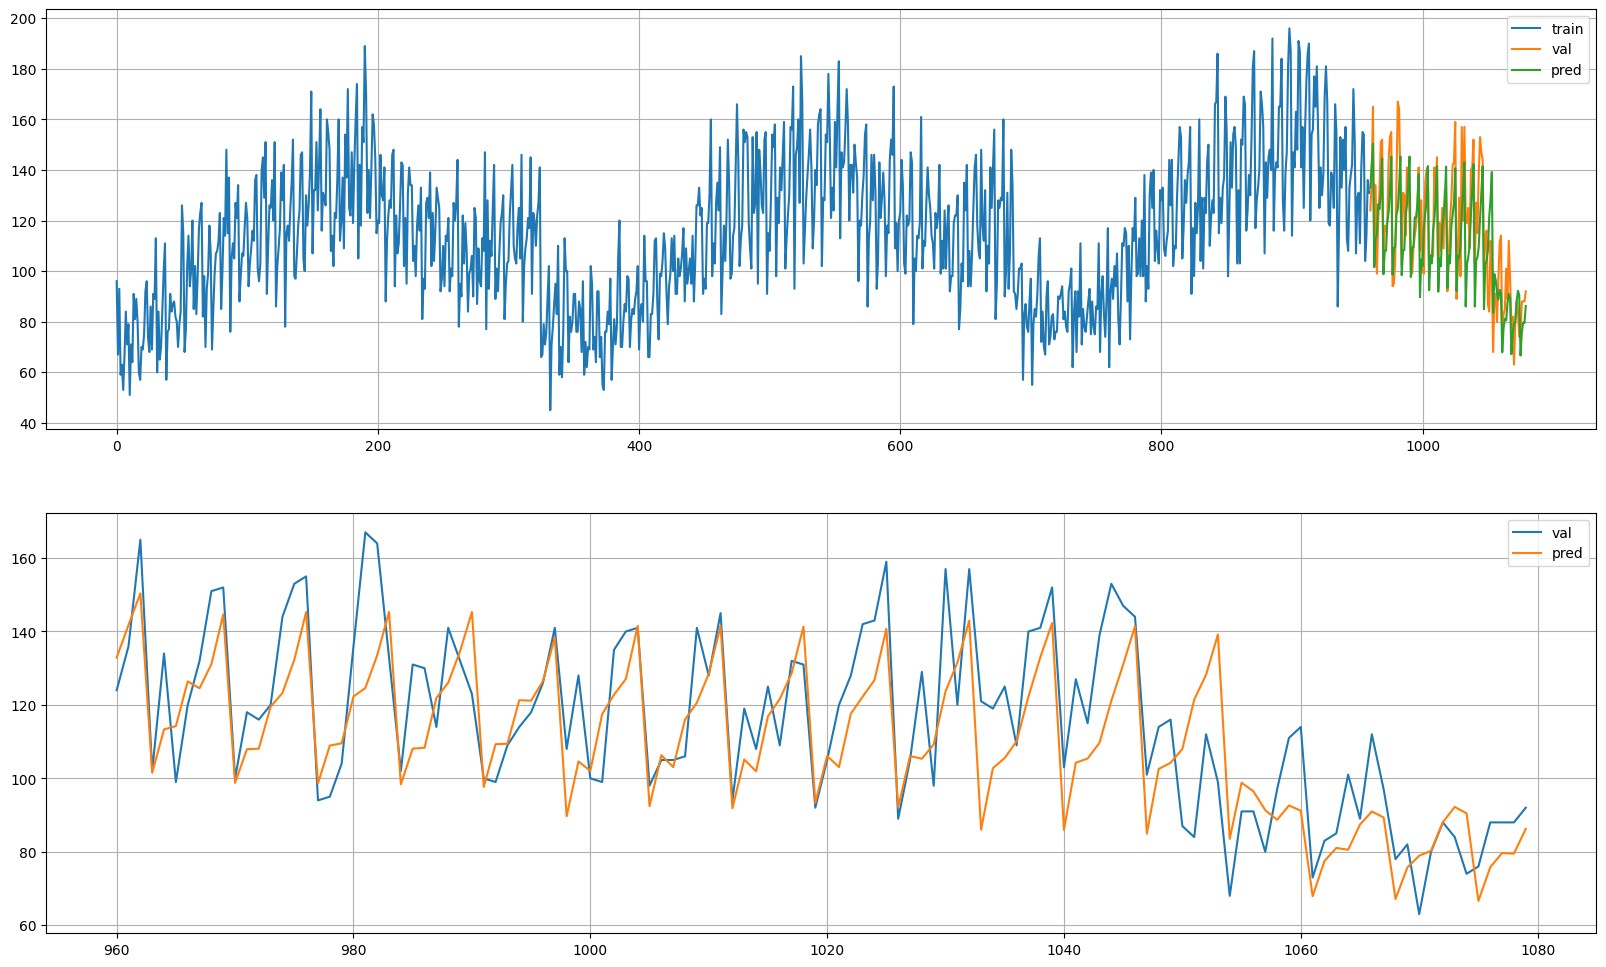

In [ ]:
y_train2 = y_train_h * (y_max - y_min) + y_min
plot_model_result(y_train2, y_val2, pred)

## **(2) CNN 초기 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

In [ ]:
#데이터 LSTM꺼 사용하면됨

* **모델링**

In [ ]:
model3=Sequential()
model3.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(x_2_train.shape[1], x_2_train.shape[2])))
model3.add(MaxPooling1D())
model3.add(Conv1D(filters=128, kernel_size=2, activation='relu'))
model3.add(MaxPooling1D())
model3.add(Flatten())

model3.add(Dense(1))
model3.compile(loss='mse',optimizer='adam',metrics=['mse'])
model3.summary()
hist3=model3.fit(x_2_train,y_2_train,epochs=100,batch_size=16,validation_data=(x_2_val,y_2_val),callbacks=[]).history

In [ ]:
plt.figure(figsize=(20,10))
plt.plot(y_2_test,label='y_test')
plt.plot(pred3,label='pred')
plt.legend()
plt.show()

---------------------------------------------------------------------

In [ ]:
model3 = Sequential([Input(shape=(timestep, nfeatures)),
                     Conv1D(filters=32, kernel_size=3, activation='relu'),
                     Conv1D(filters=8, kernel_size=3, activation='relu'),
                     Flatten(),
                     Dense(1)])

model3.compile(optimizer=Adam(0.1), loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', min_delta=0, patience=50, restore_best_weights=True)

history = model3.fit(x_train, y_train, epochs=1000, validation_data=[x_val, y_val], callbacks=[es]).history

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 27822186.0000 - mae: 3935.8584 - val_loss: 11103844.0000 - val_mae: 2462.6687
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6856390.5000 - mae: 2027.1527 - val_loss: 8650373.0000 - val_mae: 2084.7834
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5727607.0000 - mae: 1747.5833 - val_loss: 8362877.0000 - val_mae: 2031.4039
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6048773.0000 - mae: 1858.7123 - val_loss: 9777250.0000 - val_mae: 2294.8538
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6625505.0000 - mae: 1958.2965 - val_loss: 16349609.0000 - val_mae: 3314.4470
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5250005.0000 - mae: 1728.6631 - val_loss: 11509626.0000 - val_mae: 2611.0229
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5388689.0000 - mae: 1705.5968 - val_loss: 8105401.5000 - val_mae: 2172.4500
Epoch 8/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3

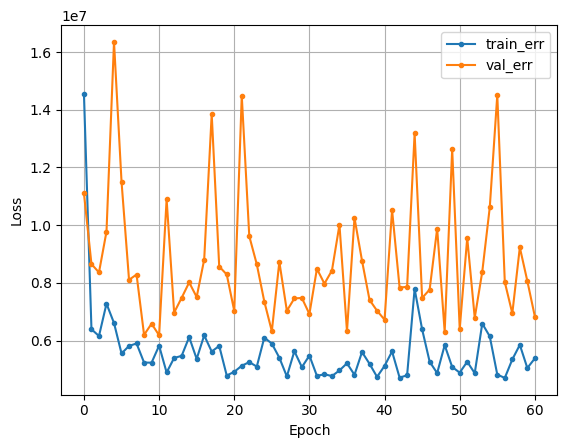

In [ ]:
dl_history_plot(history)

In [ ]:
y_pred3 = model3.predict(x_val)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [ ]:
print(root_mean_squared_error(y_val, y_pred3))
print(mean_absolute_error(y_val, y_pred3))
print(mean_absolute_percentage_error(y_val, y_pred3))
print(r2_score(y_val, y_pred3))

2486.7732
1707.2886
0.15421
0.548538088798523


In [ ]:
y_pred_test3 = model3.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [ ]:
print(root_mean_squared_error(y_test, y_pred_test3))
print(mean_absolute_error(y_test, y_pred_test3))
print(mean_absolute_percentage_error(y_test, y_pred_test3))
print(r2_score(y_test, y_pred_test3))

1442.1666
1074.7489
0.09384956
0.884770393371582


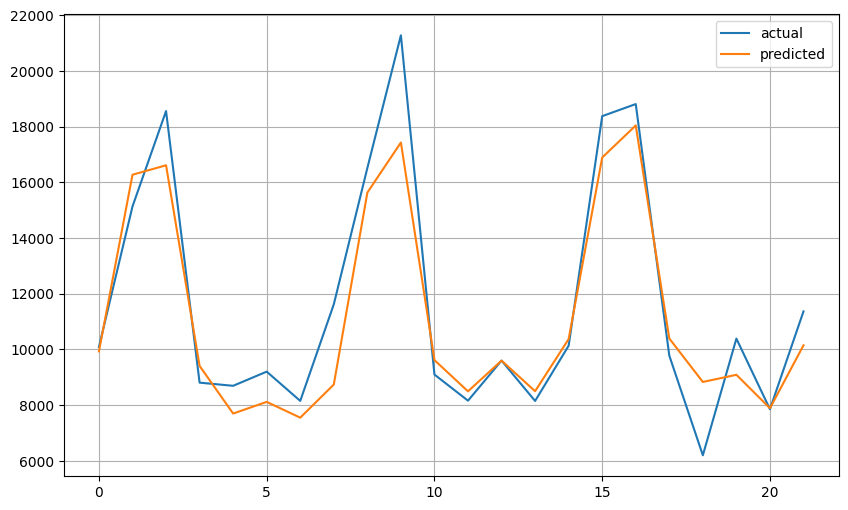

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(y_test[:100], label = 'actual')
plt.plot(y_pred_test3[:100], label = 'predicted')
plt.legend()
plt.grid()
plt.show()

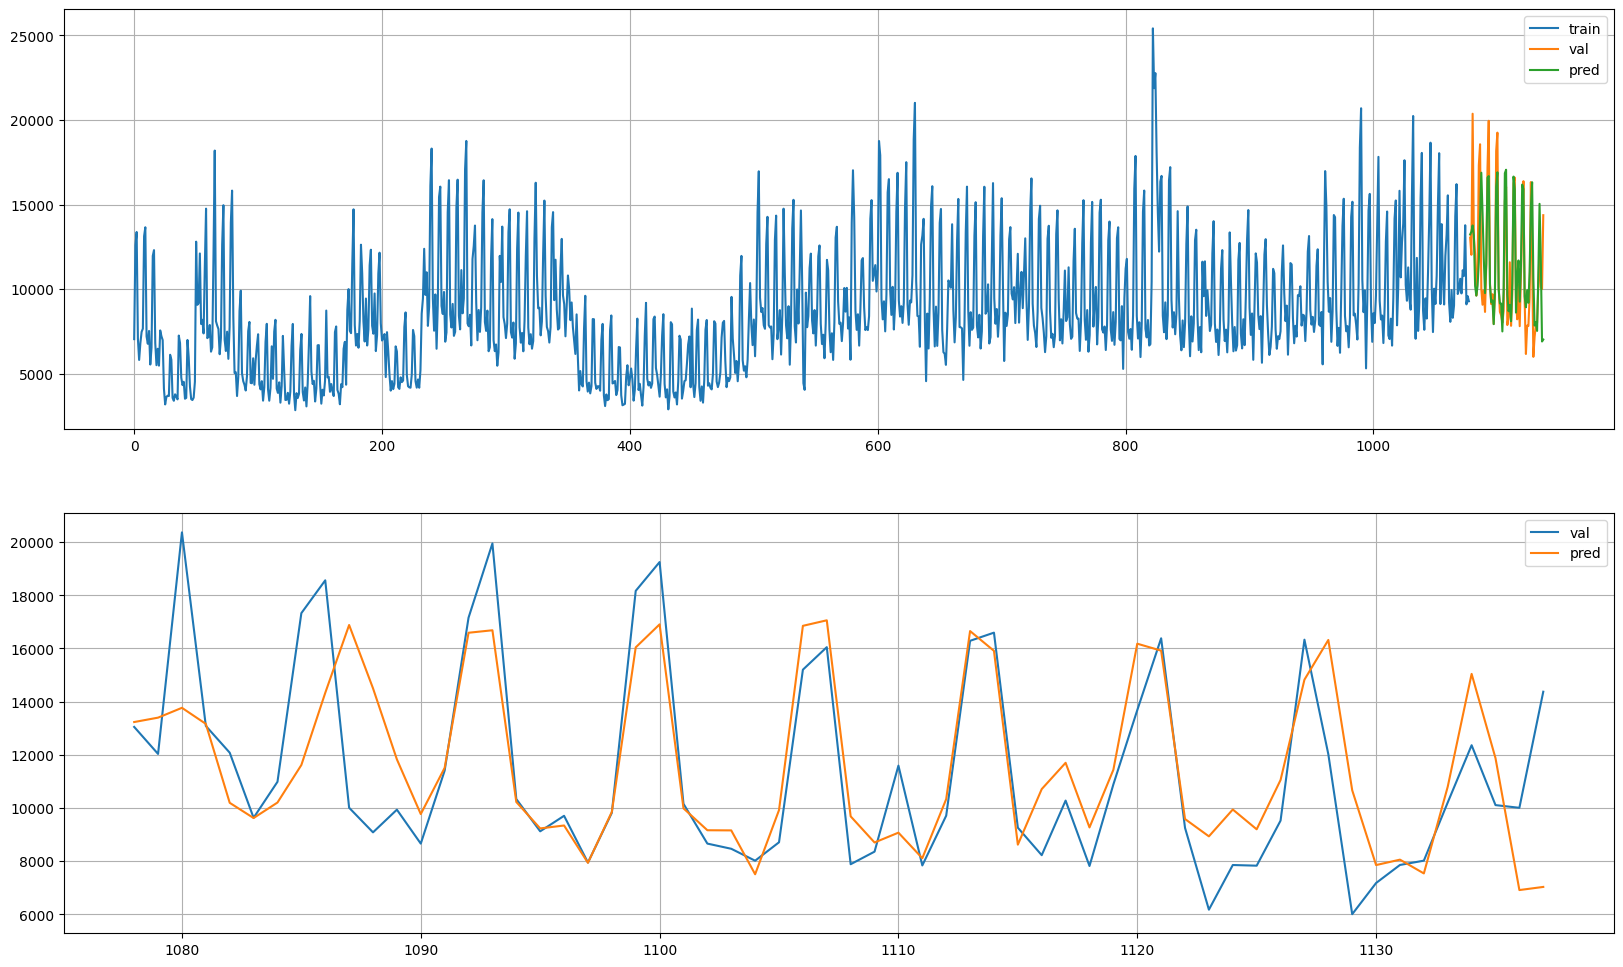

In [ ]:
plot_model_result(y_train, y_val, y_pred3)

### **2) 상품 : 12 - Milk**

* **데이터 준비**

In [ ]:
data_12

,Date,Qty,CustomerCount,WTI_Price,Month,Weekday,Is_Weekend,Prev_Qty,Qty_Weekly,Target_Qty
1,2014-01-02,9647.0,4422.0,95.140000,1,3,0,0.0,72915.0,14188.0
2,2014-01-03,8879.0,4167.0,94.400000,1,4,0,9647.0,72915.0,14490.0
3,2014-01-04,14188.0,5341.0,94.400000,1,5,1,8879.0,72915.0,7614.0
4,2014-01-05,14490.0,5123.0,94.400000,1,6,1,14188.0,72915.0,7124.0
5,2014-01-06,7614.0,3917.0,93.973333,1,0,0,14490.0,59904.0,8683.0
...,...,...,...,...,...,...,...,...,...,...
1145,2017-02-22,8931.0,3834.0,53.497857,2,2,0,7374.0,66701.0,10630.0
1146,2017-02-23,8643.0,3955.0,53.679286,2,3,0,8931.0,66701.0,12978.0
1147,2017-02-24,10630.0,4549.0,53.805000,2,4,0,8643.0,66701.0,10899.0
1148,2017-02-25,12978.0,4619.0,53.805000,2,5,1,10630.0,66701.0,10618.0


In [ ]:
timesteps = 7
x_train12, x_val12, y_train12, y_val12, scaler, y_min, y_max = preproc3d12(data_12, timesteps, True)
y_min, y_max, x_train.shape, x_val.shape

(0.0, 37106.0, (1080, 7, 3), (54, 7, 3))

* **모델링**

In [ ]:
clear_session()

_, ts, nfeat = x_train12.shape

model12_02 = Sequential([Conv1D(4, 3, input_shape = (ts, nfeat), activation='relu', padding = 'same'),
                         Flatten(),
                         Dense(1)])
model12_02.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 7, 4)                │             232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 28)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              29 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

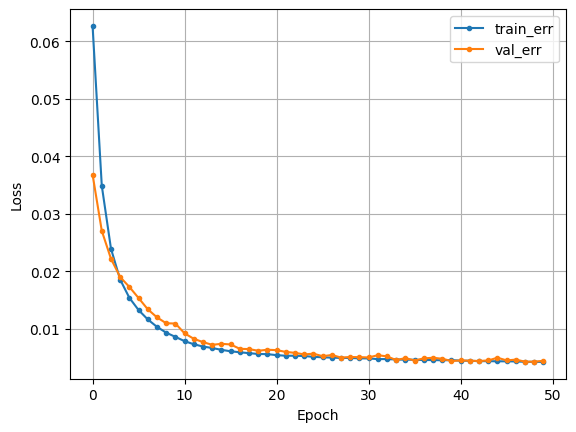

In [ ]:
model12_02.compile(optimizer = 'adam', loss = 'mse')
hist = model12_02.fit(x_train12, y_train12, epochs = 50, validation_split = .2, verbose = 0).history
dl_history_plot(hist)

In [ ]:
# 스케일링 된 데이터 돌려서 평가하기
pred = model12_02.predict(x_val12)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val12 * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
MAE :  2701.6433349609374
MAPE :  8.431747854111867e+17
R2 :  0.001443433682465356


In [ ]:
from keras.layers import MaxPooling1D

model12_03 = Sequential()

model12_03.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same', input_shape=(ts, nfeat)))
model12_03.add(MaxPooling1D(pool_size=2))
model12_03.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
model12_03.add(MaxPooling1D(pool_size=2))
model12_03.add(LSTM(100, return_sequences=False))
model12_03.add(Dense(1))
model12_03.compile(optimizer='adam', loss='mse')
model12_03.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)                    │ (None, 7, 128)              │           7,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 3, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 3, 128)              │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 100)                 │          91,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 148,405 (579.71 KB)

 Trainable params: 148,405 (579.71 KB)

 Non-trainable params: 0 (0.00 B)

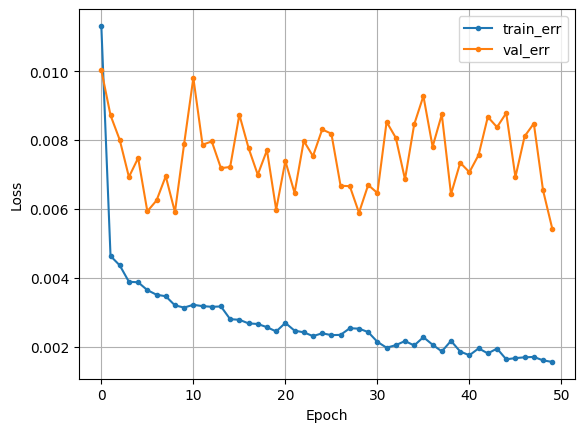

In [ ]:
model12_03.compile(optimizer = 'adam', loss = 'mse')
hist = model12_03.fit(x_train12, y_train12, epochs = 50, validation_data=(x_val12, y_val12), verbose = 0).history
dl_history_plot(hist)

In [ ]:
# 스케일링 된 데이터 돌려서 평가하기
pred = model12_03.predict(x_val12)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val12 * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
MAE :  1845.0432210286458
MAPE :  8.54326105640866e+17
R2 :  0.39614317870129223


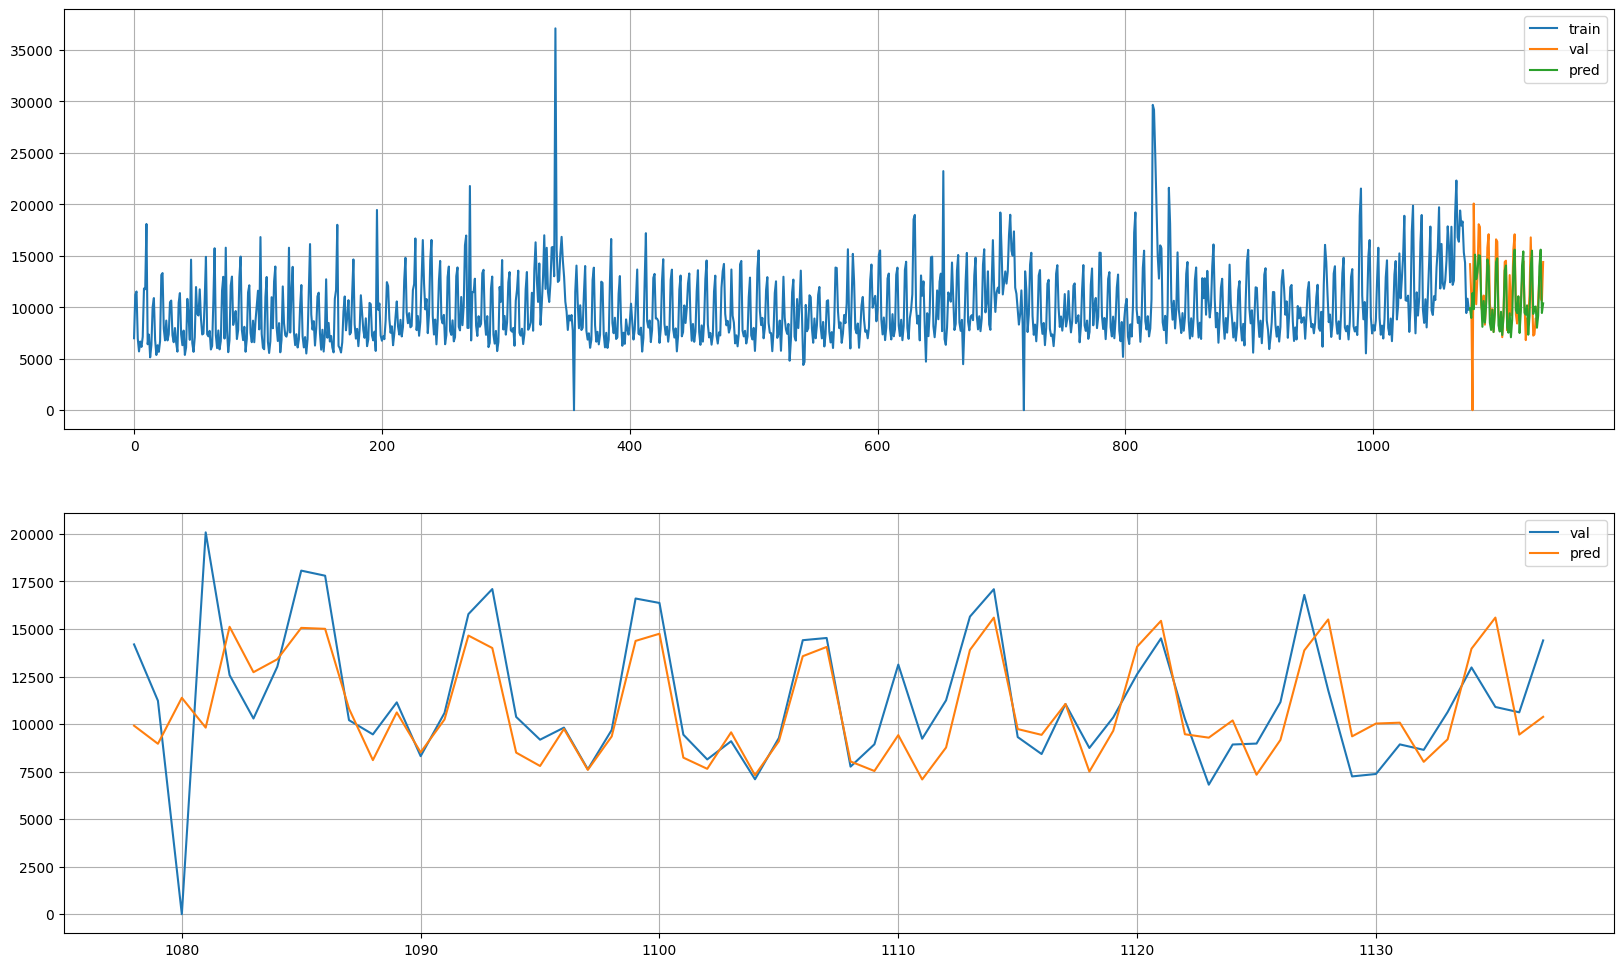

In [ ]:
y_train2 = y_train12 * (y_max - y_min) + y_min
plot_model_result(y_train2, y_val2, pred)

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

* **모델링**

In [ ]:
model3 = Sequential([Input(shape=(timesteps, n_feature)),
                     Conv1D(filters=50, kernel_size=3, activation='relu'),
                     Flatten(),
                     Dense(1)])

In [ ]:
model3.compile(optimizer=Adam(learning_rate = 0.001), loss='mse')

In [ ]:
history = model3.fit(x_train, y_train, epochs=50, validation_split=0.2).history

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0477 - val_loss: 0.0228
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0171 - val_loss: 0.0186
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0144 - val_loss: 0.0155
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0112 - val_loss: 0.0126
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0103 - val_loss: 0.0115
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0098 - val_loss: 0.0107
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084 - val_loss: 0.0109
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0080 - val_loss: 0.0099
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0079 - val_loss: 0.0097
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0078 - val_loss: 0.0097
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0079 - val_loss: 0.0096
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0071 - val_l

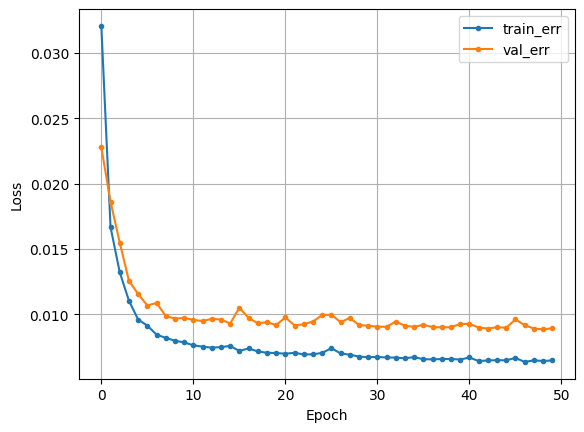

In [ ]:
dl_history_plot(history)

In [ ]:
pred3 = model3.predict(x_val)
print('MAE :', mean_absolute_error(y_val,pred3))
print('MAPE :', mean_absolute_percentage_error(y_val,pred3))
print('R2_score : ', r2_score(y_val, pred3))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
MAE : 0.06193147848232547
MAPE : 0.26652344183540244
R2_score :  0.4127568163937384


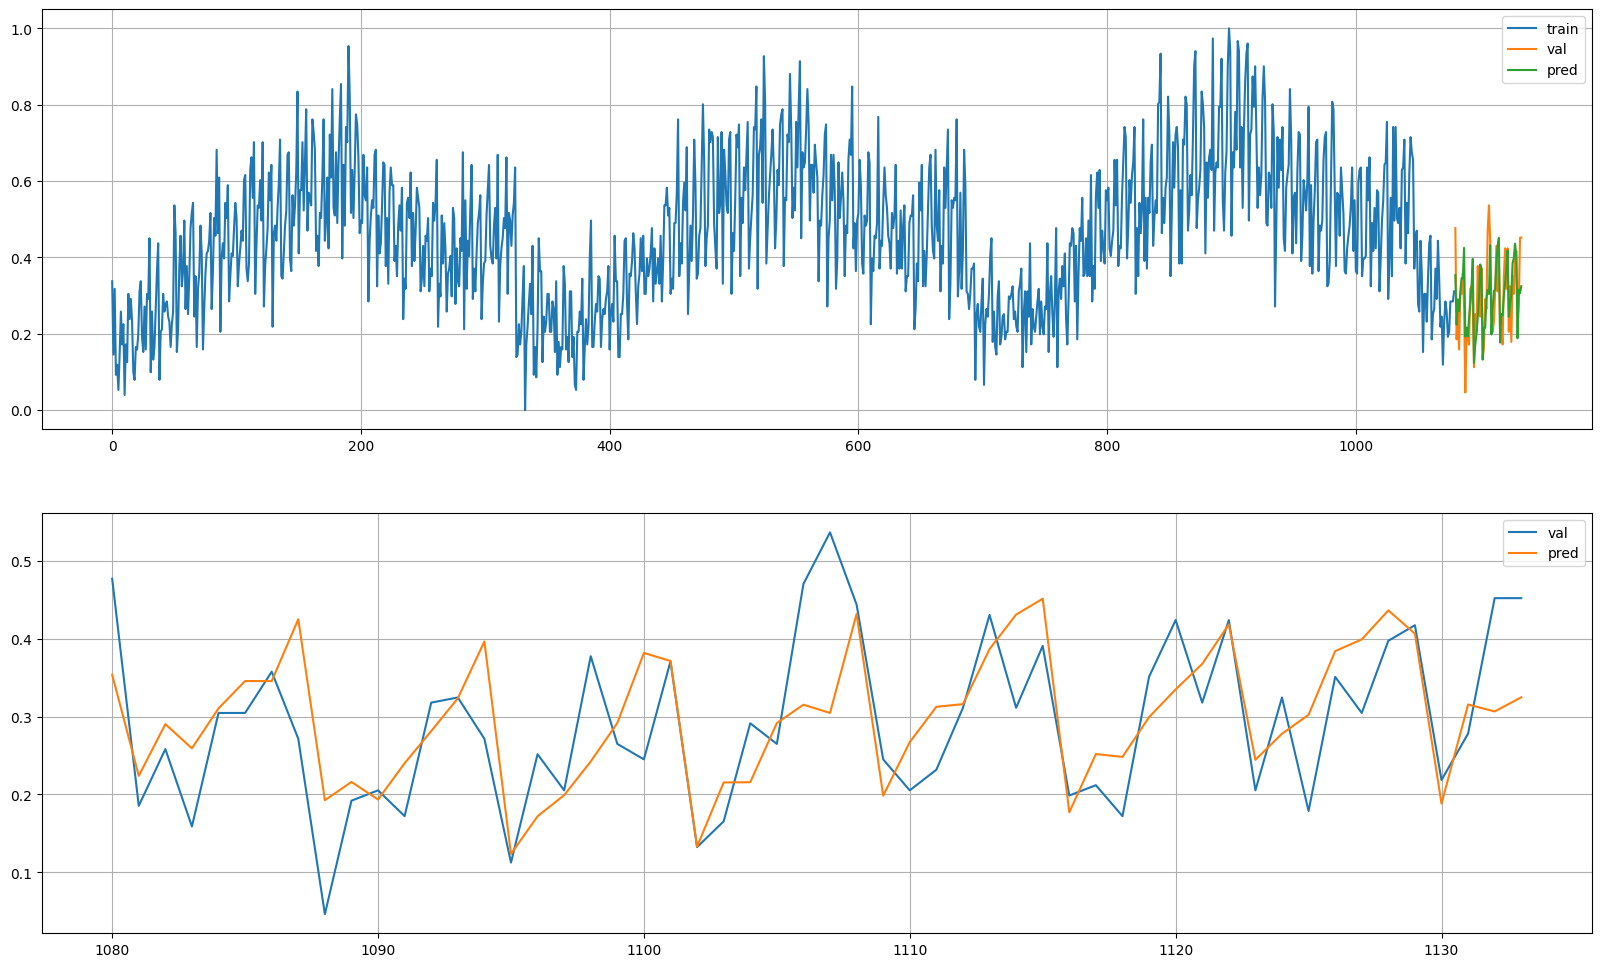

In [ ]:
plot_model_result(y_train, y_val, pred3)

In [ ]:
#농산물 모델링 2
timesteps = 7
x_train_h, x_val_h, y_train_h, y_val_h, scaler_h, y_min, y_max = preproc3d(st_df, timesteps, True)
y_min, y_max, x_train_h.shape, x_val_h.shape

(45.0, 196.0, (960, 7, 23), (120, 7, 23))

In [ ]:
from keras.layers import Conv2D
clear_session()

_, ts, nfeat = x_train_h.shape

CNN_model = Sequential([Conv1D(4, 3, input_shape = (ts, nfeat), activation='relu', padding = 'same'),
                         Flatten(),
                         Dense(1)])
CNN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 7, 4)                │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 28)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              29 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 309 (1.21 KB)

 Trainable params: 309 (1.21 KB)

 Non-trainable params: 0 (0.00 B)

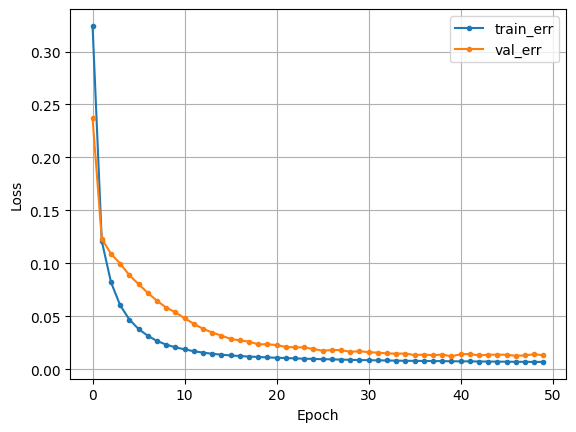

In [ ]:
CNN_model.compile(optimizer = 'adam', loss = 'mse')
CNN_hist = CNN_model.fit(x_train_h, y_train_h, epochs = 50, validation_split = .2, verbose = 0).history
dl_history_plot(CNN_hist)

In [ ]:
pred = CNN_model.predict(x_val_h)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val_h * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
MAE :  14.447499783833821
MAPE :  0.12278727991978829
R2 :  0.43149162646106853


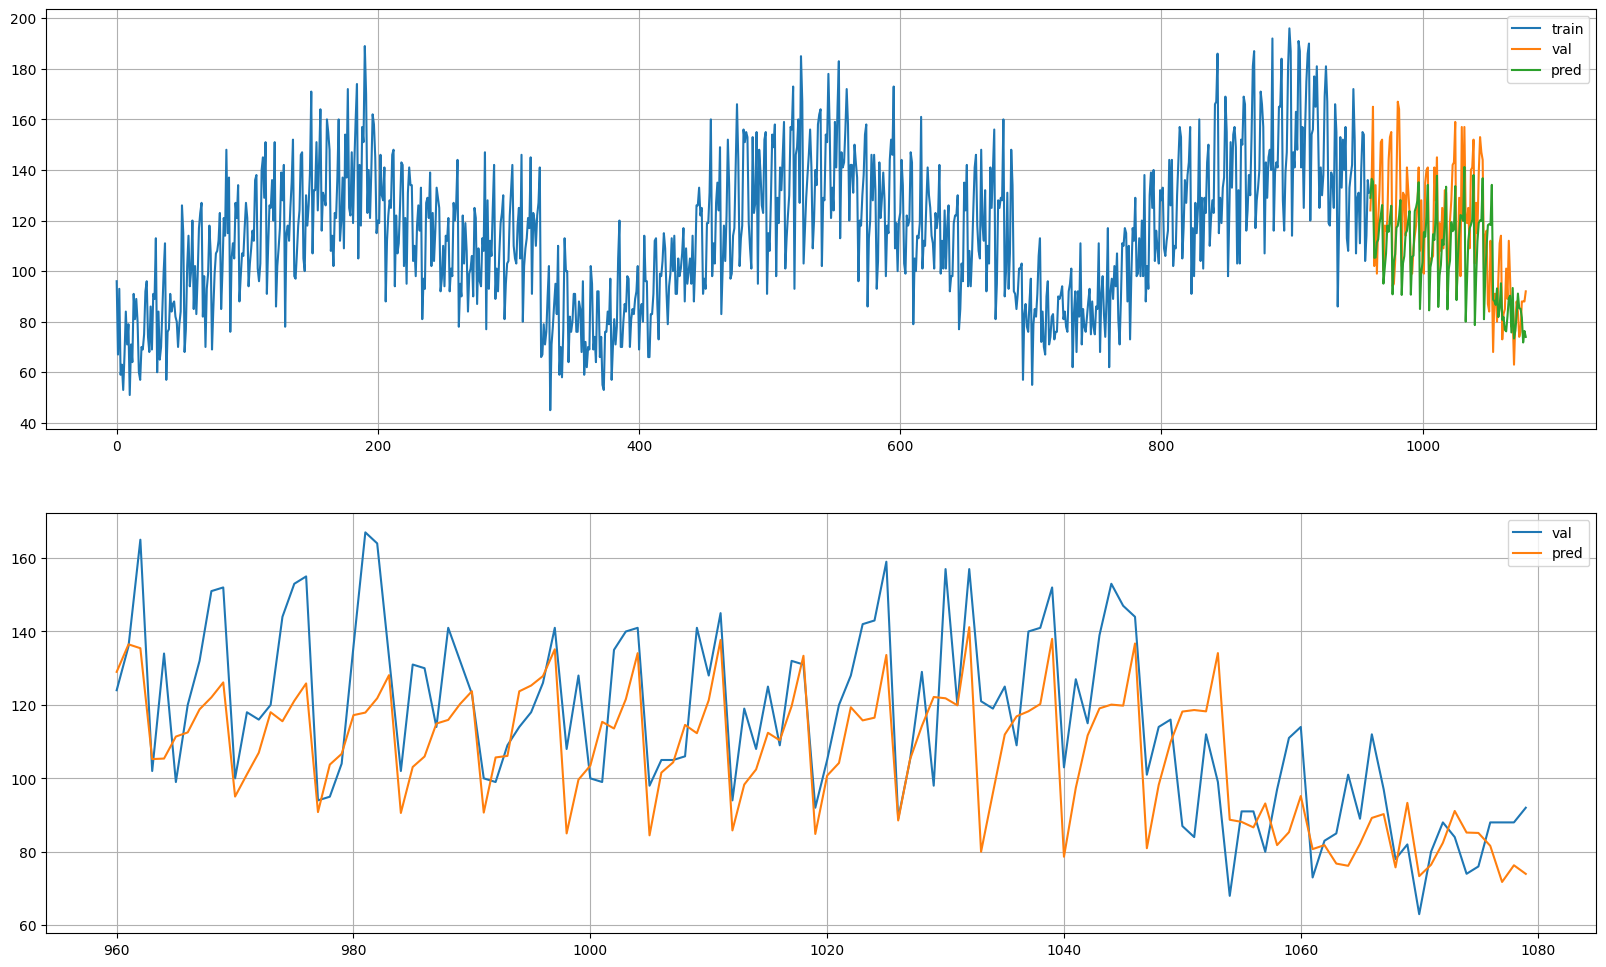

In [ ]:
y_train2 = y_train_h * (y_max - y_min) + y_min
plot_model_result(y_train2, y_val2, pred)

# **5.데이터 저장**

* **세부 요구사항**
    * 상품코드별 데이터셋을 저장하시오.
    * joblib.dump를 이용하시오.
    * 저장할 파일의 확장자는 보통 .pkl 입니다.

In [ ]:
joblib.dump(df, 'df_42.pkl')


['df_42.pkl']

In [ ]:
# 상품 코드별 데이터셋 생성
data_12 = make_dataset(12)

# 데이터를 .pkl 파일로 저장
joblib.dump(data_12, 'data_12.pkl')


['data_12.pkl']

In [ ]:
df

,Qty,CustomerCount,7days_before_Qty,2days_later_Qty
0,0.205298,0.326893,0.452436,0.218543
1,0.192053,0.283296,0.452436,0.284768
2,0.218543,0.484014,0.452436,0.132450
3,0.284768,0.446743,0.452436,0.218543
4,0.132450,0.240554,0.452436,0.185430
...,...,...,...,...
1141,0.304636,0.348607,0.423841,0.417219
1142,0.397351,0.360574,0.317881,0.218543
1143,0.417219,0.233715,0.423841,0.278146
1144,0.218543,0.248077,0.205298,0.451987


In [ ]:
#적용 컬럼 : 날짜, 유가, 방문객, 육류 재고, 요일, 월
#농산물 베이스
joblib.dump(base_model, 'base_model_44_42FM001.pkl')
#농산물 LSTM
joblib.dump(LSTM_model, 'LSTM_mode_44_42FM001.pkl')

['LSTM_mode_44_42FM001.pkl']